# DRG calcium imaging — load → preprocess → spike inference → analysis

One linear pass, top to bottom. Every expensive step is cached under `analysis_cache/`, keyed by
the parameters that produced it, so re-running is cheap and changing a parameter invalidates
exactly the artifacts that depend on it.

| § | Stage | Produces |
|---|-------|----------|
| 0 | Setup | imports · CONFIG · helpers · run manifest |
| 1 | Load | frames · time axis · ROI masks · blank control ROIs · epoch table |
| 2 | Preprocess | denoise → motion correct → ROI traces → dF/F (primary + sensitivity) |
| 3 | Spike inference | CASCADE per model · units audit · QC figure |
| 4 | Analysis | 4a features · 4b responders · 4c epoch contrasts · 4d population structure · 4e dF/F vs rate agreement |
| A | Appendix | QC comparisons · field movie · napari · exploratory sweeps · robustness panel |

## Scope and limits

- **CASCADE output is a model-estimated expected spike count per bin, never observed spikes.** It
  is not thresholded into discrete events anywhere in §0–§4, and every statement about it reads
  *inferred* or *estimated*. Edge `NaN`s stay `NaN`. (B §1.1)
- **`N mice = 1` in this notebook.** Every §4 statistic is therefore descriptive, single-animal:
  effect sizes with intervals over cells, and no p-value that treats ROIs as independent
  biological replicates. (B Executive answer, Step 9; A §1.4)
- `Spinal_cord_excitatory_30Hz_smoothing50ms` is trained on DS40 (GCaMP6s, spinal-cord excitatory
  neurons) — the nearest non-cortical calibration that exists, and the best available prior for
  this pathway (CLAUDE.md §8). It is *not* DRG ground truth; no paired Ca²⁺/ephys set exists for
  DRG, so cross-cell-type generalization here is assumed, not validated.
- With ~10 Hz imaging, **no claim about carrier phase locking, cycle skipping or n:m entrainment
  is admissible from these data.** The admissible vocabulary for a frequency-dependent decline is
  *response attenuation*, *adaptation*, or *late-envelope failure*. (B §1.3, §6.1; A §4.1)

**Requirements.** Kernel `Cajal` (numpy, scipy, scikit-image, scikit-learn, matplotlib, pandas,
tifffile, pyyaml, tqdm, ipywidgets). `ffmpeg` on PATH for the §A animation. A separate environment
with TensorFlow for §3 (CASCADE runs out-of-process). `napari` only if you turn on §A.

**First run is slow, later runs are not.** With `DENOISE_METHOD = "nlm"` the §2 trace pass is
~0.5 s/frame; on the full 3220-frame recording that is ~25 min, once. Switch to `"gaussian"` for a
fast iteration loop.

## 0. Setup

In [7]:
from __future__ import annotations

import hashlib
import itertools
import json
import os
import re
import subprocess
import warnings
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import yaml
from IPython.display import Video, display
from matplotlib import animation
from scipy import ndimage
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr
from skimage.registration import phase_cross_correlation
from skimage.restoration import denoise_nl_means
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from tqdm.auto import tqdm

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "image.interpolation": "nearest", "axes.grid": False})
print(f"numpy {np.__version__} | pandas {pd.__version__} — imports ready")

numpy 2.4.6 | pandas 3.0.2 — imports ready


### Config

**The only cell you normally edit.** Everything downstream reads from here. Keys set to `None`
have no safe default and must be declared before the pipeline will run (`check_config`, §0
helpers).

In [8]:
# ── Provenance ─────────────────────────────────────────────────────────────────
MOUSE_ID   = "leftDRGcut"    # biological replicate — the statistical unit (A §1.4, B Step 9).
SESSION_ID = "leftDRGcut-1"  # These default to the dataset folder; replace with the real animal /
FOV_ID     = "FOV1"          # session / FOV identifiers before quoting any number elsewhere.

# ── Input ──────────────────────────────────────────────────────────────────────
DATA_DIR       = Path("/Users/samsonho/KSL/leftDRGcut/raw")      # one .npy per timepoint
ROI_LABEL_PATH = Path("/Users/samsonho/KSL/leftDRGcut/_labels/Debi_DRG_ROI.tiff")
CHANNEL        = 0
TIME_RANGE_S   = None        # (start, end) seconds, or None for the whole recording

# ── Epochs — declare from TTL / lab record BEFORE inspecting effects ────────────
# The stimulus is entered in the two boxes at the bottom of this cell. Their DEFAULTS are
# onset = 3.0 s and offset = 10.0 s: a default is a convenience, NOT a declaration — until you
# type the values from the TTL/lab record, no §4 number is quotable (B Step 1, C5).
STIM_ONSET_DEFAULT_S  = 3.0   # default shown in the "stimulus onset (s)" box
STIM_OFFSET_DEFAULT_S = 10.0  # default shown in the "stimulus offset (s)" box
EPOCH_NAMES     = ("before", "within", "after")   # to subdivide (B Step 1's six-window scheme),
EXTRA_BOUNDS_S  = ()         # add names here AND the matching interior boundaries, e.g. (5.0, 30.0)
GUARD_S         = None       # None -> derived in §1c as the larger candidate (T6)
INDICATOR_TAU_S = 0.25       # indicator decay constant, s — jGCaMP8f/8m (guard candidate 1, A §2 Step 1)
GUARD_TAU_MULT  = 5          # 3-5 x tau; 5 is the conservative end of the cited range
GUARD_MODEL_BASIS = "smoothing"   # "smoothing" = CASCADE kernel half-width (T6 wording) |
                                  # "context" = the model's full input window, far more conservative
MIN_EPOCH_FRAMES = 10        # an epoch with fewer usable frames after guarding is an error

# ── Preprocess ─────────────────────────────────────────────────────────────────
DENOISE_METHOD     = "nlm"   # "nlm" | "gaussian" | "none"
NLM_PATCH_SIZE     = 5       # px, patch compared when matching
NLM_PATCH_DISTANCE = 6       # px, search radius for similar patches
NLM_H_FACTOR       = 1.15    # cut-off distance, in units of the estimated noise sigma
GAUSSIAN_SIGMA     = 2.0     # px
MOTION_CORRECT     = True    # rigid sub-pixel; shifts move the mask, not the image
MOTION_CENSOR_PX   = 3.0     # frames with |shift| above this are censored from window stats,
                             # kept as a sensitivity axis rather than silently dropped (B Step 4.5)

# ── dF/F0 — both are always computed; you choose which is primary (CR-1) ────────
F0_PRIMARY     = "static"    # one fixed reference for every epoch, so a sustained injury response
F0_SENSITIVITY = "rolling"   # is not subtracted away (B §1.2); the other is always the sensitivity
F0_PERCENTILE  = 8           # rolling: low percentile taken as baseline (A §1.2)
F0_WINDOW_S    = 60          # rolling: window length, seconds
F0_STATIC_S    = None        # static: quiet window F0 is measured over; None -> (0, stimulus
                             # onset), i.e. the first stable seconds before stimulation (B §1.2)

# ── Spike inference (§3) ───────────────────────────────────────────────────────
CASCADE_ENV_PYTHON = Path("/Users/samsonho/exit()/envs/CASCADE/bin/python")  # env WITH TensorFlow
CASCADE_ROOT       = Path("/Users/samsonho/KSL/leftDRGcut/cascade_runtime")  # cascade2p/ + Pretrained_models/
CASCADE_BRIDGE     = Path("../archive/run_cascade_ds40.py")
CASCADE_MODELS     = (       # >= 2 entries: frame-rate-matched AND tissue-matched (CR-2)
    "Global_EXC_10Hz_smoothing100ms_causalkernel",   # frame-rate matched, causal (A §1.1)
    "Spinal_cord_excitatory_30Hz_smoothing50ms",     # tissue matched, symmetric (B §1.1)
)
CASCADE_CAUSAL     = True    # required for onset / boundary claims (B §1.1, Step 6.8)

# ── Feature extraction (§4a) ───────────────────────────────────────────────────
PEAK_SMOOTH_S  = 0.5         # rolling mean before taking a peak (A §2 Step 2)
LATENCY_FRAC   = 0.2         # fraction of the epoch peak that defines dF/F onset
REBOUND_S      = 5.0         # window after an epoch used for the rebound feature (B Step 7)

# ── Response detection (§4b) ───────────────────────────────────────────────────
N_SURROGATES     = 1999      # circular-shift surrogates (B Step 8.2)
FDR_Q            = 0.05      # Benjamini-Hochberg level (B Step 8.4)
N_BLANK_ROI      = 20        # area-matched background control ROIs (A §2 Step 3)
BLANK_SEED       = 0
BLANK_MIN_SEP_PX = 6         # keep blank ROIs this far from any labelled soma
BLANK_TISSUE_PCT = 50        # blanks are placed above this intensity percentile = in tissue
BLANK_CALIB_PCT  = 95        # minimum effect size = this percentile of the blank-ROI effects
MIN_EFFECT_SCALE = 1.0       # multiplier on that threshold; the §A robustness axis moves it +/-50%

# ── Population structure (§4d) — fixed, not selected on the data (T11) ─────────
PCA_N_COMPONENTS = 3
PCA_K            = 3         # default offered in the §4d k box; you choose there, no argmax
CLUSTER_SEED     = 0
N_PERM_LABEL     = 1000      # label permutations for cluster and spatial nulls (B Step 11.5)
N_BOOT           = 2000      # hierarchical bootstrap resamples (B Step 9)

# ── Appendix-only exploratory grids (§A, never used to select §4 parameters) ────
PCA_COMP_GRID  = (2, 3, 5, 8, 12)
PCA_K_GRID     = tuple(range(2, 13))
SWEEP_MIN_S    = 20          # shortest phase the §A boundary sweep will consider
SWEEP_N_GRID   = (2, 3, 4)   # phase counts the sweep compares
WINDOW_JITTER_S = 2.0        # early/late window variation for the §A robustness panel

# ── Output ─────────────────────────────────────────────────────────────────────
USE_NAPARI   = False     # §A interactive viewer
SAVE_OUTPUTS = False     # also write every PNG / the MP4 into OUTPUT_DIR
OUTPUT_DIR   = Path("main_output")
CACHE_DIR    = Path("analysis_cache")
MOVIE_STEP   = 1         # 1 = every frame; larger = shorter preview
MOVIE_FPS    = 60        # native is ~10 Hz, so 60 fps plays back ~6x real time

# ── The stimulus, typed rather than hard-coded ─────────────────────────────────
# Positive numbers only (integer or decimal seconds), onset < offset, both inside the recording.
# §1c reads these boxes; the run manifest records the values and whether they are still defaults.
stim_onset_box = widgets.BoundedFloatText(
    value=STIM_ONSET_DEFAULT_S, min=0.01, max=1e6, step=0.1,
    description=f"stimulus onset (s)  [default {STIM_ONSET_DEFAULT_S:g}]:",
    style={"description_width": "initial"}, layout=widgets.Layout(width="420px"))
stim_offset_box = widgets.BoundedFloatText(
    value=STIM_OFFSET_DEFAULT_S, min=0.01, max=1e6, step=0.1,
    description=f"stimulus offset (s)  [default {STIM_OFFSET_DEFAULT_S:g}]:",
    style={"description_width": "initial"}, layout=widgets.Layout(width="420px"))
display(widgets.VBox([stim_onset_box, stim_offset_box]))

print(f"config read: mouse {MOUSE_ID} / session {SESSION_ID} / FOV {FOV_ID}  |  "
      f"{len(CASCADE_MODELS)} CASCADE model(s)  |  F0 primary = {F0_PRIMARY!r}  |  stimulus boxes "
      f"default to {STIM_ONSET_DEFAULT_S:g}–{STIM_OFFSET_DEFAULT_S:g} s — type the TTL/lab-record "
      f"values before quoting any §4 number (B Step 1, C5)")

config read: mouse leftDRGcut / session leftDRGcut-1 / FOV FOV1  |  2 CASCADE model(s)  |  F0 primary = 'static'  |  stimulus boxes default to 3–10 s — type the TTL/lab-record values before quoting any §4 number (B Step 1, C5)


### Shared helpers

A parameter digest for cache keys, a build-or-load wrapper, a figure saver, the config contract,
and the run-manifest accumulator. Nothing else in the notebook touches disk caching directly.
The one decision to check: `check_config()` raises rather than defaulting (B Step 1, C5).

In [9]:
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)          # tables always land here, figures if asked

REQUIRED_KEYS = ("MOUSE_ID", "SESSION_ID", "FOV_ID", "STIM_ONSET_DEFAULT_S",
                 "STIM_OFFSET_DEFAULT_S", "INDICATOR_TAU_S", "F0_PRIMARY", "F0_SENSITIVITY",
                 "CASCADE_MODELS")
MANIFEST: dict[str, dict] = {}


def digest(*parts, n: int = 10) -> str:
    """Short md5 over any mix of scalars, strings, paths and arrays."""
    h = hashlib.md5()
    for part in parts:
        h.update(np.ascontiguousarray(part).tobytes() if isinstance(part, np.ndarray)
                 else repr(part).encode())
    return h.hexdigest()[:n]


def cached(path: Path, build, overwrite: bool = False):
    """Load `path` if it exists, otherwise call `build()` and save the result.

    `build` may return an array (saved as .npy) or a dict of arrays (saved as .npz).
    Cache keys must be built with `digest` so that changing a parameter changes the path.
    """
    if path.exists() and not overwrite:
        if path.suffix == ".npz":
            with np.load(path) as data:
                return {k: data[k] for k in data.files}
        return np.load(path)
    result = build()
    if isinstance(result, dict):
        np.savez_compressed(path, **result)
    else:
        np.save(path, result)
    return result


def save_fig(fig, name: str) -> None:
    """Write a figure to OUTPUT_DIR when SAVE_OUTPUTS is on. Figures always show inline."""
    if SAVE_OUTPUTS:
        fig.savefig(OUTPUT_DIR / f"{name}.png", dpi=200, bbox_inches="tight")


def offdiag(matrix: np.ndarray) -> np.ndarray:
    """Upper-triangle (i < j) entries of a square matrix, as a flat vector."""
    return matrix[np.triu_indices(matrix.shape[0], 1)]


def record(section: str, **entries) -> None:
    """Add entries to the run manifest (§0 -> §4, written out at the end of §4)."""
    MANIFEST.setdefault(section, {}).update(entries)


def write_manifest(path: Path = CACHE_DIR / "run_manifest.json") -> Path:
    """Serialise the reproducibility record (B §9)."""
    def plain(obj):
        if isinstance(obj, (np.integer, np.floating)):
            return obj.item()
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return str(obj)
    path.write_text(json.dumps(MANIFEST, indent=2, default=plain, sort_keys=True))
    return path


def check_config() -> None:
    """Refuse to run on an undeclared decision. Every branch here names the offending key."""
    unset = [k for k in REQUIRED_KEYS if globals()[k] in (None, (), "", "...")]
    if unset:
        raise ValueError(
            "CONFIG incomplete — set " + ", ".join(unset) + " in the Config cell. "
            "These have no safe default: epochs must be declared from the TTL/lab record before "
            "effects are inspected (B Step 1), and F0/model choices are left open on purpose "
            "(Conflict register CR-1, CR-2).")
    if len(CASCADE_MODELS) < 2:
        raise ValueError("CASCADE_MODELS needs >= 2 entries: one frame-rate-matched and one "
                         "tissue-matched model (CR-2).")
    if {F0_PRIMARY, F0_SENSITIVITY} != {"static", "rolling"}:
        raise ValueError("F0_PRIMARY and F0_SENSITIVITY must be 'static' and 'rolling' in some "
                         "order — both are always computed (CR-1).")
    if len(EXTRA_BOUNDS_S) + 2 != len(EPOCH_NAMES) - 1:
        raise ValueError(f"EPOCH_NAMES declares {len(EPOCH_NAMES)} epochs, which needs "
                         f"{len(EPOCH_NAMES) - 3} entries in EXTRA_BOUNDS_S on top of the stimulus "
                         f"onset and offset — got {len(EXTRA_BOUNDS_S)}.")
    if GUARD_MODEL_BASIS not in ("smoothing", "context"):
        raise ValueError(f"GUARD_MODEL_BASIS must be 'smoothing' or 'context' — got "
                         f"{GUARD_MODEL_BASIS!r}.")


check_config()
record("provenance", mouse_id=MOUSE_ID, session_id=SESSION_ID, fov_id=FOV_ID,
       data_dir=DATA_DIR, roi_label_path=ROI_LABEL_PATH, channel=CHANNEL,
       time_range_s=TIME_RANGE_S, n_mice=1, n_sessions=1, n_fovs=1)
print(f"cache -> {CACHE_DIR}/  |  tables -> {OUTPUT_DIR}/  |  "
      + ("figures also saved" if SAVE_OUTPUTS else "figures inline only")
      + "  |  config contract OK")

cache -> analysis_cache/  |  tables -> main_output/  |  figures inline only  |  config contract OK


## 1. Load

Frame stack (one `.npy` per timepoint, SlideBook export) and the ROI mask TIFF. The time axis
comes from `ElapsedTimes.yaml` rather than being assumed: acquisition timestamps jitter by a
millisecond or two and §3 divides by real bin widths.

In [10]:
_TP = re.compile(r"_TP(\d+)\.npy$")


def index_frames(data_dir: Path, channel: int) -> list[Path]:
    """Frame files for one channel, ordered by timepoint."""
    files = [p for p in data_dir.glob(f"ImageData_Ch{channel}_TP*.npy") if _TP.search(p.name)]
    if not files:
        raise FileNotFoundError(
            f"No frames matched {data_dir}/ImageData_Ch{channel}_TP*.npy — "
            "check DATA_DIR and CHANNEL in the Config cell."
        )
    return sorted(files, key=lambda p: int(_TP.search(p.name).group(1)))


def elapsed_times(n: int, data_dir: Path) -> np.ndarray:
    """Per-frame acquisition time in seconds, starting at 0."""
    path = data_dir / "ElapsedTimes.yaml"
    if path.is_file():
        raw = yaml.safe_load(path.read_text())["theElapsedTimes"][1:]  # [0] is a count
        t = np.asarray(raw, dtype=float)[:n] / 1000.0
        if t.size == n:
            return t - t[0]
        print(f"! ElapsedTimes has {len(raw)} entries for {n} frames — assuming 10 Hz")
    return np.arange(n, dtype=float) / 10.0


def bin_edges_s(t: np.ndarray) -> np.ndarray:
    """Midpoint bin edges — the same contract the CASCADE bridge uses for its Hz conversion."""
    edges = np.empty(t.size + 1, dtype=np.float64)
    edges[1:-1] = (t[:-1] + t[1:]) / 2
    edges[0] = t[0] - (t[1] - t[0]) / 2
    edges[-1] = t[-1] + (t[-1] - t[-2]) / 2
    return edges


def slidebook_scalar(key: str, data_dir: Path, name: str = "ImageRecord.yaml") -> float | None:
    """One scalar from a SlideBook YAML, by line scan — these files also embed a large
    thumbnail array that is pointless to parse."""
    path = data_dir / name
    if path.is_file():
        for line in path.read_text().splitlines():
            if f"{key}:" in line:
                return float(line.split(":")[1])
    return None


def load_frame(i: int) -> np.ndarray:
    """One raw (H, W) frame, untouched."""
    return np.load(frame_files[i]).squeeze(axis=0)


frame_files = index_frames(DATA_DIR, CHANNEL)
times_s = elapsed_times(len(frame_files), DATA_DIR)
if TIME_RANGE_S is not None:                 # applied once; every later section inherits it
    keep = (times_s >= TIME_RANGE_S[0]) & (times_s <= TIME_RANGE_S[1])
    frame_files = [p for p, k in zip(frame_files, keep) if k]
    times_s = times_s[keep] - times_s[keep][0]

n_frames = len(frame_files)
frame_shape = load_frame(0).shape
dt_s = np.diff(bin_edges_s(times_s))                     # per-frame bin width, seconds
fps = 1.0 / float(np.median(np.diff(times_s)))
pixel_um = slidebook_scalar("mMicronPerPixel", DATA_DIR)
exposure_ms = slidebook_scalar("mExposureTime", DATA_DIR, "ChannelRecord.yaml")

record("acquisition", n_frames=n_frames, frame_shape=list(frame_shape), fps_hz=round(fps, 4),
       t_start_s=float(times_s[0]), t_end_s=float(times_s[-1]), pixel_um=pixel_um,
       exposure_ms=exposure_ms, median_bin_width_s=float(np.median(dt_s)),
       bin_width_jitter_ms=float(1000 * (dt_s.max() - dt_s.min())))
print(f"{n_frames} frames of {frame_shape[0]}x{frame_shape[1]}  |  "
      f"t = 0–{times_s[-1]:.1f} s  |  {fps:.2f} Hz"
      + (f"  |  {pixel_um:.3f} um/px" if pixel_um else "")
      + (f"  |  {exposure_ms:.0f} ms exposure" if exposure_ms else "")
      + (f"  [windowed to {TIME_RANGE_S}]" if TIME_RANGE_S else ""))

3220 frames of 1024x1376  |  t = 0–322.2 s  |  10.00 Hz  |  0.880 um/px  |  100 ms exposure


### 1b. ROI masks and blank control ROIs

Real ROIs come from the label TIFF. `N_BLANK_ROI` blank controls are then placed in labelled
tissue away from every soma, area-matched to the real ROI area distribution, and carried through
every downstream step with an `is_blank` flag (A §2 Step 3, B Step 8). The one decision to check:
blanks must sit in tissue, not on the coverslip — inspect them in the §2 QC figure.

In [11]:
def load_roi_masks(path: Path, shape: tuple[int, int]):
    """Integer label TIFF (0 = background, 1..N = one ROI each) -> labels, ids, masks."""
    labels = np.rint(np.squeeze(tifffile.imread(path))).astype(np.int32)
    if labels.shape != shape:
        raise ValueError(f"ROI label shape {labels.shape} != frame shape {shape}")
    ids = np.unique(labels)
    ids = ids[ids > 0]
    if ids.size == 0:
        raise ValueError(f"No positive labels in {path}")
    return labels, ids, np.stack([labels == i for i in ids])


def sample_blank_rois(real_masks: np.ndarray, areas_px: np.ndarray, preview: np.ndarray,
                      n_blank: int = N_BLANK_ROI, seed: int = BLANK_SEED) -> np.ndarray:
    """Disk ROIs in tissue, area-matched to `areas_px`, `BLANK_MIN_SEP_PX` clear of every soma."""
    rng = np.random.default_rng(seed)
    tissue = preview >= np.percentile(preview, BLANK_TISSUE_PCT)
    taken = ndimage.binary_dilation(real_masks.any(axis=0), iterations=BLANK_MIN_SEP_PX)
    height, width = preview.shape
    rows, cols = np.mgrid[0:height, 0:width]
    out = []
    for target_area in rng.choice(areas_px, size=n_blank, replace=True):
        radius = float(np.sqrt(target_area / np.pi))
        for _ in range(2000):
            cy = rng.integers(int(radius) + 1, height - int(radius) - 1)
            cx = rng.integers(int(radius) + 1, width - int(radius) - 1)
            disk = (rows - cy) ** 2 + (cols - cx) ** 2 <= radius ** 2
            if disk.sum() and not (disk & taken).any() and tissue[disk].mean() > 0.9:
                out.append(disk)
                taken |= ndimage.binary_dilation(disk, iterations=BLANK_MIN_SEP_PX)
                break
        else:
            raise RuntimeError(
                f"Could not place blank ROI {len(out) + 1}/{n_blank} of area {target_area} px — "
                "lower N_BLANK_ROI/BLANK_MIN_SEP_PX or BLANK_TISSUE_PCT.")
    return np.stack(out)


label_map, roi_ids, real_masks = load_roi_masks(ROI_LABEL_PATH, frame_shape)
preview_frame = np.mean([load_frame(int(i)).astype(np.float32)
                         for i in np.linspace(0, n_frames - 1, 12).astype(int)], axis=0)
real_area_px = real_masks.reshape(len(real_masks), -1).sum(axis=1).astype(np.int64)
blank_masks = sample_blank_rois(real_masks, real_area_px, preview_frame)

roi_masks = np.concatenate([real_masks, blank_masks])
n_roi, n_real, n_blank = len(roi_masks), len(real_masks), len(blank_masks)
roi_area_px = roi_masks.reshape(n_roi, -1).sum(axis=1).astype(np.int64)
roi_centroids = np.array([ndimage.center_of_mass(m) for m in roi_masks])   # (row, col)
roi_labels = [str(int(i)) for i in roi_ids] + [f"blank{j + 1:02d}" for j in range(n_blank)]
is_blank = np.arange(n_roi) >= n_real

roi_table = pd.DataFrame({
    "roi": roi_labels, "is_blank": is_blank, "area_px": roi_area_px,
    "y_px": roi_centroids[:, 0].round(1), "x_px": roi_centroids[:, 1].round(1),
})
record("rois", n_cells_real=n_real, n_cells_blank=n_blank, roi_label_file=ROI_LABEL_PATH.name,
       blank_seed=BLANK_SEED, blank_min_sep_px=BLANK_MIN_SEP_PX,
       blank_tissue_pct=BLANK_TISSUE_PCT, neuropil_subtraction=False)
print(f"{n_real} real ROIs + {n_blank} blank controls  |  real area "
      f"{real_area_px.min()}–{real_area_px.max()} px (median {np.median(real_area_px):.0f})  |  "
      f"blank median {np.median(roi_area_px[is_blank]):.0f} px")

40 real ROIs + 20 blank controls  |  real area 1207–7412 px (median 3259)  |  blank median 2769 px


### 1c. Epoch table and guard band

Epochs come from the two stimulus boxes in Config (plus `EXTRA_BOUNDS_S`) — declared from the
TTL/lab record, never chosen by optimising a statistic (B Step 1, C5). Interior boundaries are
guarded by ±`GUARD_S`, the larger of 3–5 × indicator τ (A §2 Step 1) and the CASCADE model path
selected by `GUARD_MODEL_BASIS` (B Step 6.8); all three candidates are printed. The one decision
to check: whether the boxes still hold the defaults — the cell says so if they do.

In [12]:
def model_spec(model: str) -> dict:
    """Rate, smoothing and temporal context of a CASCADE model.

    Read from the model's `config.yaml` when the model is present under CASCADE_ROOT; otherwise
    parsed from the model name with CASCADE's defaults (windowsize 64, before_frac 0.5).
    """
    cfg_path = CASCADE_ROOT / "Pretrained_models" / model / "config.yaml"
    if cfg_path.is_file():
        cfg = yaml.safe_load(cfg_path.read_text())
        return {"model": model, "source": "config.yaml",
                "rate_hz": float(cfg["sampling_rate"]), "smoothing_s": float(cfg["smoothing"]),
                "windowsize": int(cfg["windowsize"]), "before_frac": float(cfg["before_frac"]),
                "causal": bool(int(cfg.get("causal_kernel", 0)))}
    rate = re.search(r"_(\d+(?:\.\d+)?)Hz", model)
    smooth = re.search(r"smoothing(\d+)ms", model)
    if not (rate and smooth):
        raise ValueError(f"Cannot read a rate/smoothing from model name {model!r} and "
                         f"{cfg_path} is absent — download the model or rename it.")
    return {"model": model, "source": "model name",
            "rate_hz": float(rate.group(1)), "smoothing_s": int(smooth.group(1)) / 1000.0,
            "windowsize": 64, "before_frac": 0.5, "causal": model.endswith("_causalkernel")}


STIM_ONSET_S = float(stim_onset_box.value)          # the two boxes at the bottom of Config
STIM_OFFSET_S = float(stim_offset_box.value)
STIM_IS_DEFAULT = (STIM_ONSET_S == STIM_ONSET_DEFAULT_S) and (STIM_OFFSET_S == STIM_OFFSET_DEFAULT_S)
if not 0 < STIM_ONSET_S < STIM_OFFSET_S:
    raise ValueError(f"stimulus onset/offset must be positive with onset < offset — got "
                     f"{STIM_ONSET_S} / {STIM_OFFSET_S} s.")
if STIM_OFFSET_S >= times_s[-1]:
    raise ValueError(f"stimulus offset {STIM_OFFSET_S} s is at or past the end of the "
                     f"{times_s[-1]:.1f} s recording.")

model_specs = {m: model_spec(m) for m in CASCADE_MODELS}
guard_indicator_s = GUARD_TAU_MULT * float(INDICATOR_TAU_S)          # A §2 Step 1
guard_smoothing_s = max(2 * s["smoothing_s"] for s in model_specs.values())
guard_context_s = max(max(s["before_frac"], 1 - s["before_frac"]) * s["windowsize"] / s["rate_hz"]
                      + 2 * s["smoothing_s"] for s in model_specs.values())
guard_model_s = guard_smoothing_s if GUARD_MODEL_BASIS == "smoothing" else guard_context_s
guard_s = float(max(guard_indicator_s, guard_model_s) if GUARD_S is None else GUARD_S)
guard_path = ("indicator tau path" if guard_indicator_s >= guard_model_s
              else f"model {GUARD_MODEL_BASIS} path")

EPOCH_BOUNDS_S = tuple(sorted(float(b) for b in (STIM_ONSET_S, STIM_OFFSET_S, *EXTRA_BOUNDS_S)))
edges_s = [float(times_s[0]), *EPOCH_BOUNDS_S, float(times_s[-1])]
if any(b <= a for a, b in zip(edges_s, edges_s[1:])):
    raise ValueError(f"epoch boundaries must be strictly increasing inside the recording: {edges_s}")

# The guard is applied at *interior* boundaries only: the start and end of the recording have no
# neighbouring epoch to leak from (A §2 Step 1 places it at the stimulus-offset boundary).
epoch_rows, epoch_masks = [], {}
for k, (name, start, end) in enumerate(zip(EPOCH_NAMES, edges_s[:-1], edges_s[1:])):
    role = ("before" if end <= STIM_ONSET_S + 1e-9 else
            "within" if start >= STIM_ONSET_S - 1e-9 and end <= STIM_OFFSET_S + 1e-9 else "after")
    lo = start + (guard_s if k > 0 else 0.0)
    hi = end - (guard_s if k < len(EPOCH_NAMES) - 1 else 0.0)
    declared = (times_s > start) & (times_s <= end)
    guarded = (times_s >= lo) & (times_s <= hi)
    if guarded.sum() < MIN_EPOCH_FRAMES:
        raise ValueError(
            f"epoch {name!r} ({start:.1f}–{end:.1f} s) keeps only {int(guarded.sum())} frames after "
            f"the {guard_s:.2f} s guard, below MIN_EPOCH_FRAMES = {MIN_EPOCH_FRAMES}. Either widen "
            "the epoch, or set GUARD_MODEL_BASIS = 'smoothing', or state a shorter INDICATOR_TAU_S "
            "— do not shrink the guard below the indicator tail you actually have (A §2 Step 1).")
    epoch_masks[name] = guarded
    epoch_rows.append({"epoch": name, "role": role, "t_start_s": start, "t_end_s": end,
                       "t_used_start_s": round(lo, 2), "t_used_end_s": round(hi, 2),
                       "frames_declared": int(declared.sum()), "frames_after_guard": int(guarded.sum()),
                       "duration_used_s": float(dt_s[guarded].sum())})

epochs = pd.DataFrame(epoch_rows)
if not (epochs["role"] == "before").any():
    raise ValueError("no epoch lies entirely before STIM_ONSET_S — every contrast in §4 is taken "
                     "against a declared pre-stimulus epoch (B Step 1).")
baseline_epoch = epochs.loc[epochs["role"] == "before", "epoch"].iloc[-1]
within_epochs = list(epochs.loc[epochs["role"] == "within", "epoch"])
after_epochs = list(epochs.loc[epochs["role"] == "after", "epoch"])
durations = epochs["duration_used_s"]
record("epochs", bounds_s=list(EPOCH_BOUNDS_S), names=list(EPOCH_NAMES),
       stim_onset_s=STIM_ONSET_S, stim_offset_s=STIM_OFFSET_S,
       stim_source="typed into the §0 boxes",
       stim_still_at_default=bool(STIM_IS_DEFAULT),
       stim_defaults_s=[STIM_ONSET_DEFAULT_S, STIM_OFFSET_DEFAULT_S],
       guard_s=guard_s, guard_candidate_indicator_s=guard_indicator_s,
       guard_candidate_model_smoothing_s=guard_smoothing_s,
       guard_candidate_model_context_s=guard_context_s, guard_model_basis=GUARD_MODEL_BASIS,
       guard_path=guard_path, guard_applied="interior boundaries only",
       guard_overridden_by_config=GUARD_S is not None,
       indicator_tau_s=float(INDICATOR_TAU_S), guard_tau_multiple=GUARD_TAU_MULT,
       table=epochs.to_dict("records"), baseline_epoch=baseline_epoch, n_trials=1)
display(epochs)
if STIM_IS_DEFAULT:
    print(f"! the stimulus boxes are still at their defaults ({STIM_ONSET_DEFAULT_S:g} / "
          f"{STIM_OFFSET_DEFAULT_S:g} s). A default is not a declaration: type the TTL/lab-record "
          "values before quoting any §4 number (B Step 1, C5).")
if durations.max() > 2 * durations.min():
    print(f"! epoch durations differ by {durations.max() / durations.min():.1f}x "
          f"({durations.min():.1f}–{durations.max():.1f} s): compare `mean_value` (a rate) across "
          "epochs, not `integral`, which scales with window length (B Step 1).")
print(f"GUARD_S = {guard_s:.2f} s (candidates: {guard_indicator_s:.2f} s indicator tau path / "
      f"{guard_smoothing_s:.2f} s model smoothing-kernel path / {guard_context_s:.2f} s model "
      f"input-context path; basis = {GUARD_MODEL_BASIS} -> {guard_path}"
      + (", overridden by CONFIG" if GUARD_S is not None else "")
      + ", applied at interior boundaries only)  |  stimulus "
      f"{STIM_ONSET_S:g}–{STIM_OFFSET_S:g} s  |  baseline epoch {baseline_epoch!r}  |  "
      f"within {within_epochs}  |  after {after_epochs}")

,epoch,role,t_start_s,t_end_s,t_used_start_s,t_used_end_s,frames_declared,frames_after_guard,duration_used_s
0,before,before,0.0,3.000,0.00,1.75,29,18,1.7995
1,within,within,3.0,10.000,4.25,8.75,70,45,4.5040
2,after,after,10.0,322.217,11.25,322.22,3120,3107,311.0070


! the stimulus boxes are still at their defaults (3 / 10 s). A default is not a declaration: type the TTL/lab-record values before quoting any §4 number (B Step 1, C5).
! epoch durations differ by 172.8x (1.8–311.0 s): compare `mean_value` (a rate) across epochs, not `integral`, which scales with window length (B Step 1).
GUARD_S = 1.25 s (candidates: 1.25 s indicator tau path / 0.20 s model smoothing-kernel path / 3.40 s model input-context path; basis = smoothing -> indicator tau path, applied at interior boundaries only)  |  stimulus 3–10 s  |  baseline epoch 'before'  |  within ['within']  |  after ['after']


## 2. Preprocess

**denoise → motion-correct → extract traces → dF/F**, in the order CLAUDE.md §3 recommends. The
traces and the max-intensity projection come out of a single streaming pass, so the raw frames are
read from disk exactly once.

### 2a. Denoise

Non-local means preserves edges by averaging over *similar patches* rather than neighbouring
pixels; a Gaussian blur of comparable strength smears the somatic boundary. NLM costs ~0.5 s/frame
against a few ms for the Gaussian — the side-by-side comparison is in §A.

In [13]:
_LAPLACIAN = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=np.float32)


def noise_sigma(frame: np.ndarray) -> float:
    """Immerkaer's Laplacian noise estimate — numpy/scipy only, so no PyWavelets needed."""
    h, w = frame.shape
    response = np.abs(ndimage.convolve(frame.astype(np.float32), _LAPLACIAN, mode="nearest"))
    return float(response.sum() * np.sqrt(0.5 * np.pi) / (6.0 * (w - 2) * (h - 2)))


def denoise(frame: np.ndarray, method: str | None = None) -> np.ndarray:
    """Denoise one frame with the configured method (or an explicit override)."""
    method = DENOISE_METHOD if method is None else method
    frame = frame.astype(np.float32)
    if method == "none":
        return frame
    if method == "gaussian":
        return ndimage.gaussian_filter(frame, GAUSSIAN_SIGMA)
    if method == "nlm":
        sigma = noise_sigma(frame)
        return denoise_nl_means(
            frame, h=NLM_H_FACTOR * sigma, sigma=sigma, fast_mode=True,
            patch_size=NLM_PATCH_SIZE, patch_distance=NLM_PATCH_DISTANCE, channel_axis=None,
        ).astype(np.float32)
    raise ValueError(f"DENOISE_METHOD must be 'nlm', 'gaussian' or 'none' — got {method!r}")


record("preprocess", denoise_method=DENOISE_METHOD, nlm_patch_size=NLM_PATCH_SIZE,
       nlm_patch_distance=NLM_PATCH_DISTANCE, nlm_h_factor=NLM_H_FACTOR,
       gaussian_sigma_px=GAUSSIAN_SIGMA, motion_correct=MOTION_CORRECT,
       motion_censor_px=MOTION_CENSOR_PX)
_frame0 = load_frame(0).astype(np.float32)
print(f"denoise = {DENOISE_METHOD}  |  frame 0 sigma_hat: raw {noise_sigma(_frame0):.2f} -> "
      f"denoised {noise_sigma(denoise(_frame0)):.2f}")

denoise = nlm  |  frame 0 sigma_hat: raw 36.10 -> denoised 1.25


### 2b. Motion correction (rigid)

Field-wide motion adds the *same* fluctuation to every ROI, so it inflates §4d correlations
directly. Each frame is registered to a template built from the ~100 quietest frames by sub-pixel
phase cross-correlation. **The shifts move the mask, not the image** — §2c samples raw pixel
`(r − dy, c − dx)` for mask pixel `(r, c)`. Rigid registration sees *lateral* displacement only:
axial drift and lamp fluctuation are invisible here by construction, so a clean panel narrows the
candidates rather than clearing them. The per-frame metric is exported for §4 (B Step 4.5).

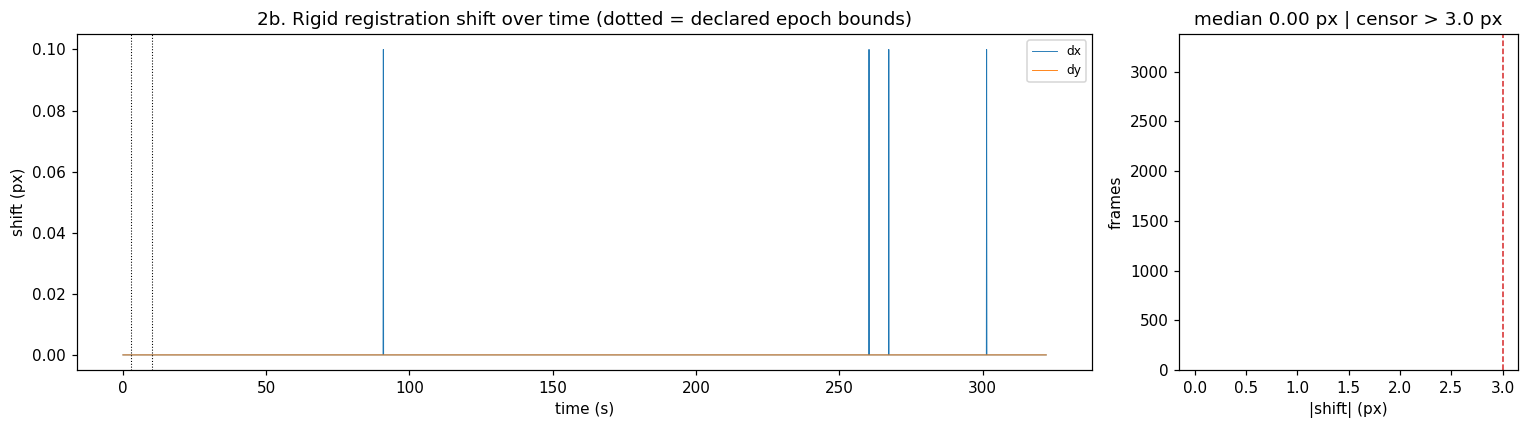

|shift|: median 0.00 px, 95th pct 0.00 px, max 0.10 px  |  0/3220 frames censored at 3.0 px  |  per-frame metric -> main_output/motion_per_frame.csv


In [14]:
MOTION_TEMPLATE_N = 100      # frames averaged into the registration template
MOTION_SAMPLE_STEP = 8       # subsample used to find the quietest frames


def _mean_frame(indices) -> np.ndarray:
    acc = np.zeros(frame_shape, dtype=np.float64)
    for i in indices:
        acc += load_frame(int(i))
    return (acc / len(indices)).astype(np.float32)


def _shifts_to(template: np.ndarray, indices, desc: str) -> np.ndarray:
    out = np.empty((len(indices), 2))
    for k, i in enumerate(tqdm(indices, desc=desc)):
        out[k] = phase_cross_correlation(
            template, load_frame(int(i)).astype(np.float32), upsample_factor=10)[0]
    return out


def compute_motion() -> dict:
    """(dy, dx) per frame that aligns it to a template of the quietest frames."""
    sample = np.arange(0, n_frames, MOTION_SAMPLE_STEP)
    rough = _shifts_to(_mean_frame(sample), sample, "motion: template pass")
    quiet = np.sort(sample[np.argsort(np.hypot(*rough.T))[:MOTION_TEMPLATE_N]])
    template = _mean_frame(quiet)
    return {"shifts": _shifts_to(template, np.arange(n_frames), "motion: registering"),
            "template": template}


if MOTION_CORRECT:
    motion = cached(
        CACHE_DIR / f"motion_ch{CHANNEL}_{digest(n_frames, times_s, MOTION_TEMPLATE_N)}.npz",
        compute_motion,
    )
    shifts, mc_template = motion["shifts"], motion["template"]
else:
    shifts = np.zeros((n_frames, 2))
    mc_template = _mean_frame(np.arange(0, n_frames, 50))
    print("motion correction DISABLED (MOTION_CORRECT = False)")

motion_px = np.hypot(*shifts.T)                       # per-frame motion covariate (B Step 4.5)
motion_censored = motion_px > MOTION_CENSOR_PX
pd.DataFrame({"frame": np.arange(n_frames), "time_s": times_s, "shift_dy_px": shifts[:, 0],
              "shift_dx_px": shifts[:, 1], "motion_px": motion_px,
              "censored": motion_censored}).to_csv(OUTPUT_DIR / "motion_per_frame.csv", index=False)

fig, (ax_t, ax_h) = plt.subplots(1, 2, figsize=(14, 4), width_ratios=[3, 1])
ax_t.plot(times_s, shifts[:, 1], lw=0.6, label="dx")
ax_t.plot(times_s, shifts[:, 0], lw=0.6, label="dy")
for b in EPOCH_BOUNDS_S:
    ax_t.axvline(float(b), color="k", ls=":", lw=0.7)
ax_t.set_xlabel("time (s)"); ax_t.set_ylabel("shift (px)"); ax_t.legend(fontsize=8)
ax_t.set_title("2b. Rigid registration shift over time (dotted = declared epoch bounds)")
ax_h.hist(motion_px, bins=50, color="tab:grey")
ax_h.axvline(MOTION_CENSOR_PX, color="tab:red", ls="--", lw=1.0)
ax_h.set_xlabel("|shift| (px)"); ax_h.set_ylabel("frames")
ax_h.set_title(f"median {np.median(motion_px):.2f} px | censor > {MOTION_CENSOR_PX} px")
fig.tight_layout()
save_fig(fig, "2b_motion_qc")
plt.show()

record("preprocess", motion_template_n=MOTION_TEMPLATE_N, motion_sample_step=MOTION_SAMPLE_STEP,
       motion_median_px=float(np.median(motion_px)), motion_p95_px=float(np.percentile(motion_px, 95)),
       n_frames_censored=int(motion_censored.sum()),
       motion_metric_file=str(OUTPUT_DIR / "motion_per_frame.csv"))
print(f"|shift|: median {np.median(motion_px):.2f} px, 95th pct {np.percentile(motion_px, 95):.2f} px, "
      f"max {motion_px.max():.2f} px  |  {int(motion_censored.sum())}/{n_frames} frames censored at "
      f"{MOTION_CENSOR_PX} px  |  per-frame metric -> {OUTPUT_DIR}/motion_per_frame.csv")

### 2c. ROI traces

One streaming pass computes the per-ROI mean of the **denoised** frame (real ROIs and blank
controls alike) plus a raw max-intensity projection. Only the `(n_frames, n_roi)` trace array and
the projection are cached. These are plain ROI means: no neuropil annulus, no background
subtraction — so read §4d correlation levels as an upper bound.

In [15]:
def extract_traces() -> dict:
    """Stream the recording once: denoised per-ROI means, plus a raw max projection.

    Motion is applied to the mask indices (rounded to whole pixels), so mask pixel (r, c)
    samples raw pixel (r - dy, c - dx). All ROIs are read in one flat gather per frame via
    `np.add.reduceat`, which is why this is a single pass rather than one pass per ROI.
    """
    rows = np.concatenate([np.nonzero(m)[0] for m in roi_masks]).astype(np.int64)
    cols = np.concatenate([np.nonzero(m)[1] for m in roi_masks]).astype(np.int64)
    offsets = np.concatenate([[0], np.cumsum(roi_area_px)[:-1]]).astype(np.int64)
    height, width = frame_shape

    F = np.empty((n_frames, n_roi), dtype=np.float32)
    max_proj = np.zeros(frame_shape, dtype=np.float32)
    for i in tqdm(range(n_frames), desc=f"traces + max projection ({DENOISE_METHOD})"):
        raw = load_frame(i)
        np.maximum(max_proj, raw, out=max_proj)
        flat = denoise(raw).ravel()
        dy, dx = np.rint(shifts[i]).astype(int)
        rr = np.clip(rows - dy, 0, height - 1)
        cc = np.clip(cols - dx, 0, width - 1)
        F[i] = np.add.reduceat(flat[rr * width + cc], offsets) / roi_area_px
    return {"F": F, "max_proj": max_proj}


TRACE_KEY = digest(DENOISE_METHOD, NLM_PATCH_SIZE, NLM_PATCH_DISTANCE, NLM_H_FACTOR,
                   GAUSSIAN_SIGMA, label_map, roi_masks, shifts, times_s)
traces = cached(CACHE_DIR / f"traces_ch{CHANNEL}_{DENOISE_METHOD}_{TRACE_KEY}.npz", extract_traces)
F_roi, max_proj = traces["F"], traces["max_proj"]
record("preprocess", trace_cache_key=TRACE_KEY,
       f_median_real=float(np.median(F_roi[:, ~is_blank])),
       f_median_blank=float(np.median(F_roi[:, is_blank])))
print(f"F {F_roi.shape} ({n_real} real + {n_blank} blank ROIs)  |  median F "
      f"{np.median(F_roi[:, ~is_blank]):.0f} real vs {np.median(F_roi[:, is_blank]):.0f} blank")

traces + max projection (nlm):   0%|          | 0/3220 [00:00<?, ?it/s]

F (3220, 60) (40 real + 20 blank ROIs)  |  median F 907 real vs 942 blank


### 2d. dF/F0 — both baselines, every run

`static` fixes one reference for all epochs so a sustained response is not subtracted away
(B §1.2); `rolling` tracks photobleaching and lens settling (A §1.2). Which is *primary* is a
config decision, not a default (CR-1) — the other is always carried as the sensitivity trace.
The drift audit fits a mono-exponential to each pre-stimulus segment and extrapolates it, so the
bleach a fixed F₀ would mistake for an after-effect is a number, not a worry (A §1.2, B Step 5.3).

In [16]:
F0_STATIC_WINDOW_S = (0.0, STIM_ONSET_S) if F0_STATIC_S is None else tuple(F0_STATIC_S)
if F0_STATIC_WINDOW_S[1] > STIM_ONSET_S + 1e-9:
    raise ValueError(f"F0_STATIC_S ends at {F0_STATIC_WINDOW_S[1]} s, after the stimulus onset at "
                     f"{STIM_ONSET_S} s — the fixed baseline must be measured before stimulation "
                     "(B §1.2).")


def to_dff(F: np.ndarray) -> dict[str, np.ndarray]:
    """(F - F0) / F0 per column under both baseline definitions. Keys: 'static', 'rolling'."""
    F = np.asarray(F, dtype=np.float64)
    sel = (times_s >= F0_STATIC_WINDOW_S[0]) & (times_s <= F0_STATIC_WINDOW_S[1])
    if sel.sum() < 3:
        raise ValueError(f"the static F0 window {F0_STATIC_WINDOW_S} covers only "
                         f"{int(sel.sum())} frames")
    window = max(3, round(F0_WINDOW_S * fps))
    out = {}
    for name, F0 in (("static", np.median(F[sel], axis=0, keepdims=True)),
                     ("rolling", ndimage.percentile_filter(F, F0_PERCENTILE, size=(window, 1),
                                                           mode="nearest"))):
        out[name] = ((F - np.clip(F0, 1e-3, None)) / np.clip(F0, 1e-3, None)).astype(np.float32)
    return out


def bleach_audit(F: np.ndarray) -> pd.DataFrame:
    """Mono-exponential fit on each pre-stimulus segment, extrapolated to the end of the recording.

    Reports the predicted bleach at t_end as a fraction of the static F0 — the size of the
    'activity decreased after stimulation' artefact a fixed baseline would inherit.
    """
    pre = times_s < STIM_ONSET_S
    t = times_s[pre]
    rows = []
    for j in range(F.shape[1]):
        y = F[pre, j].astype(np.float64)
        f0 = float(np.median(y[:max(3, int(round(fps)))]))
        try:
            with warnings.catch_warnings():                  # a failed fit is reported, not shouted
                warnings.simplefilter("ignore")
                (a, tau, c), _ = curve_fit(
                    lambda x, a, tau, c: a * np.exp(-x / tau) + c, t - t[0], y,
                    p0=(y[0] - y[-1] or 1.0, max(t[-1] - t[0], 1.0), y[-1]), maxfev=5000)
                pred_end = a * np.exp(-(times_s[-1] - t[0]) / tau) + c
            ok, tau_s, frac = tau > 0, float(tau), float((pred_end - (a + c)) / max(f0, 1e-3))
        except Exception:
            ok, tau_s, frac = False, np.nan, np.nan
        rows.append({"roi": roi_labels[j], "is_blank": bool(is_blank[j]), "fit_ok": ok,
                     "tau_s": tau_s, "predicted_bleach_at_t_end_frac_F0": frac})
    return pd.DataFrame(rows)


dff = to_dff(F_roi)                                    # {"static": (n_frames, n_roi), "rolling": ...}
drift = bleach_audit(F_roi)
drift.to_csv(OUTPUT_DIR / "drift_audit.csv", index=False)
F0_TAG = {"static": f"static median of {F0_STATIC_WINDOW_S[0]:g}–{F0_STATIC_WINDOW_S[1]:g}s",
          "rolling": f"rolling {F0_WINDOW_S}s / {F0_PERCENTILE}th pct"}
METHOD_TAG = f"denoise: {DENOISE_METHOD.upper()}  |  F0 primary: {F0_TAG[F0_PRIMARY]}"
median_bleach = float(np.nanmedian(drift.loc[drift["fit_ok"], "predicted_bleach_at_t_end_frac_F0"]))
record("dff", primary=F0_PRIMARY, sensitivity=F0_SENSITIVITY,
       static_window_s=list(F0_STATIC_WINDOW_S),
       rolling_percentile=F0_PERCENTILE, rolling_window_s=F0_WINDOW_S,
       formula="(F - F0) / F0, F0 clipped at 1e-3", units="fraction (not percent)",
       drift_method="mono-exponential fit on the pre-stimulus segment, extrapolated to t_end",
       median_predicted_bleach_at_t_end_frac_F0=median_bleach,
       n_drift_fits_ok=int(drift["fit_ok"].sum()), drift_file=str(OUTPUT_DIR / "drift_audit.csv"))
print(f"dff['static'] {dff['static'].shape} and dff['rolling'] {dff['rolling'].shape} both built  |  "
      f"primary = {F0_PRIMARY}  |  drift audit: {int(drift['fit_ok'].sum())}/{n_roi} fits, median "
      f"predicted bleach at t_end = {100 * median_bleach:+.1f}% of F0")

dff['static'] (3220, 60) and dff['rolling'] (3220, 60) both built  |  primary = static  |  drift audit: 56/60 fits, median predicted bleach at t_end = -6.1% of F0


### 2e. Preprocessing QC

ROIs on the max projection (blank controls dashed), the primary dF/F for every ROI as a heatmap,
and the population mean with the declared epochs shaded. The one thing to check: blank controls
should sit in tissue and show no epoch-locked structure.

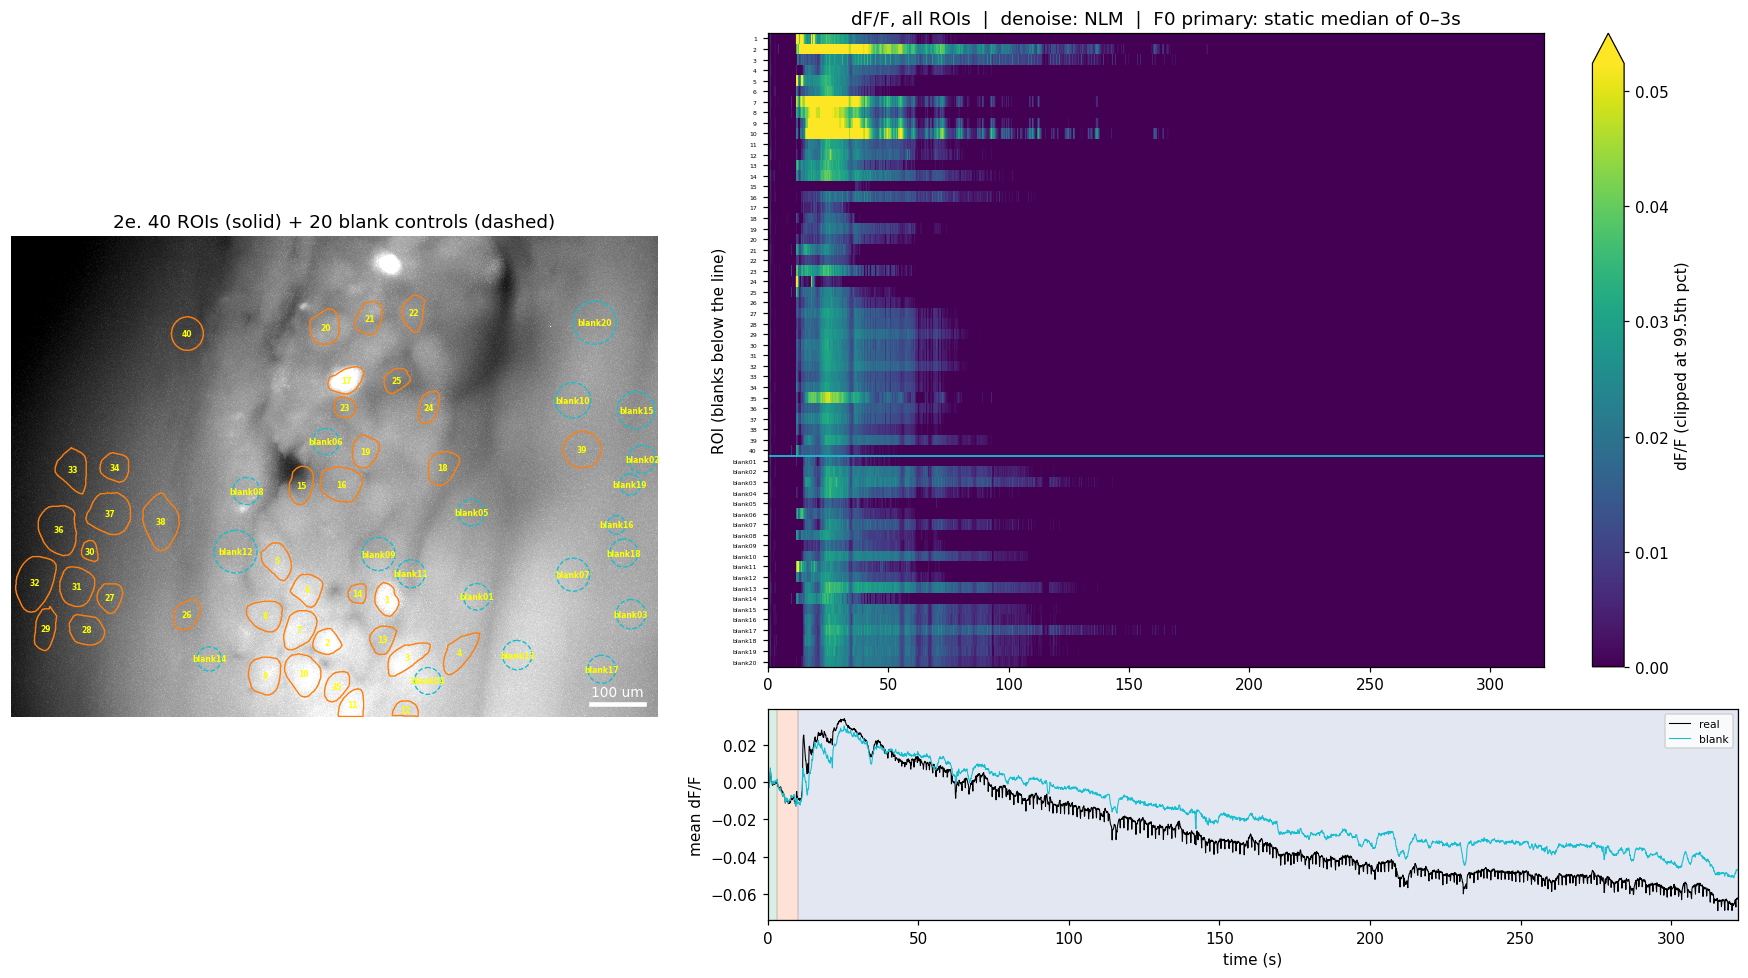

QC rendered  |  dF/F range real [-0.13, 0.18] vs blank [-0.09, 0.07]  |  epochs shaded from EPOCH_BOUNDS_S


In [17]:
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.5], height_ratios=[3, 1])
ax_f = fig.add_subplot(gs[:, 0])
ax_h = fig.add_subplot(gs[0, 1])
ax_m = fig.add_subplot(gs[1, 1], sharex=ax_h)

vmin, vmax = np.percentile(max_proj, [2, 99.5])
ax_f.imshow(max_proj, cmap="gray", vmin=vmin, vmax=vmax)
for j, mask in enumerate(roi_masks):
    ax_f.contour(mask, levels=[0.5], colors=["tab:cyan" if is_blank[j] else "tab:orange"],
                 linewidths=0.9, linestyles="dashed" if is_blank[j] else "solid")
    ax_f.text(roi_centroids[j, 1], roi_centroids[j, 0], roi_labels[j],
              color="yellow", fontsize=5, ha="center", va="center", weight="bold")
if pixel_um:                                   # 100 um scale bar, bottom-right
    bar_px = 100.0 / pixel_um
    ax_f.plot([frame_shape[1] - bar_px - 30, frame_shape[1] - 30], [frame_shape[0] - 30] * 2,
              color="white", lw=3)
    ax_f.text(frame_shape[1] - bar_px / 2 - 30, frame_shape[0] - 45, "100 um", color="white",
              ha="center", fontsize=9)
ax_f.set_title(f"2e. {n_real} ROIs (solid) + {n_blank} blank controls (dashed)")
ax_f.axis("off")

primary = dff[F0_PRIMARY]
clip = float(np.percentile(primary, 99.5))
im = ax_h.imshow(primary.T, aspect="auto", cmap="viridis", vmin=0, vmax=max(clip, 1e-3),
                 extent=[times_s[0], times_s[-1], n_roi - 0.5, -0.5])
fig.colorbar(im, ax=ax_h, extend="max", label="dF/F (clipped at 99.5th pct)")
ax_h.axhline(n_real - 0.5, color="tab:cyan", lw=1.2)
ax_h.set_yticks(range(n_roi)); ax_h.set_yticklabels(roi_labels, fontsize=4)
ax_h.set_ylabel("ROI (blanks below the line)")
ax_h.set_title(f"dF/F, all ROIs  |  {METHOD_TAG}")
ax_m.plot(times_s, primary[:, ~is_blank].mean(axis=1), lw=0.7, color="k", label="real")
ax_m.plot(times_s, primary[:, is_blank].mean(axis=1), lw=0.7, color="tab:cyan", label="blank")
for k, row in epochs.iterrows():
    ax_m.axvspan(row["t_start_s"], row["t_end_s"], color=plt.cm.Set2(k % 8), alpha=0.25)
ax_m.set_xlabel("time (s)"); ax_m.set_ylabel("mean dF/F"); ax_m.legend(fontsize=7)
fig.tight_layout()
save_fig(fig, "2e_preprocess_qc")
plt.show()
print(f"QC rendered  |  dF/F range real [{primary[:, ~is_blank].min():.2f}, "
      f"{primary[:, ~is_blank].max():.2f}] vs blank [{primary[:, is_blank].min():.2f}, "
      f"{primary[:, is_blank].max():.2f}]  |  epochs shaded from EPOCH_BOUNDS_S")

## 3. Spike inference — CASCADE

Run every configured model on **both** dF/F baselines. Changing F₀ rescales dF/F and therefore
CASCADE's absolute calibration, so the sensitivity trace gets its own inference run — a rescaled
prediction is never reused (B §1.2). CASCADE needs TensorFlow, which is not in this kernel, so it
runs out-of-process via `archive/run_cascade_ds40.py`. The bridge resamples the ~10 Hz recording
to the model's rate, predicts, and sums the model bins back into native bins; `spike_rate_native_hz`
is divided by the width of *each* native bin, and the assertion below pins that contract.

In [19]:
def run_cascade(traces_rt: np.ndarray, t_s: np.ndarray, model: str) -> dict:
    """Run the bridge in the CASCADE environment. `traces_rt` is (n_roi, n_time) dF/F.

    Cached by the content of its inputs, so re-running with unchanged traces is free and changing
    a single sample forces a fresh prediction. The input is raw dF/F: no z-scoring, no added
    smoothing (C3, B Step 6.2).
    """
    traces_rt = np.ascontiguousarray(traces_rt, dtype=np.float32)
    t_s = np.ascontiguousarray(t_s, dtype=np.float64)
    if not np.isfinite(traces_rt).all():
        raise ValueError("CASCADE input has NaN/inf — it cannot accept censored bins. Motion "
                         "censoring is applied to window statistics in §4, not to the bridge input "
                         "(A §6).")

    key = hashlib.md5(traces_rt.tobytes() + t_s.tobytes() + model.encode()).hexdigest()[:12]
    in_path = CACHE_DIR / f"cascade_input_{key}.npz"
    out_path = CACHE_DIR / f"cascade_{key}.npz"

    if not out_path.exists():
        for label, path in (("env Python", CASCADE_ENV_PYTHON), ("bridge", CASCADE_BRIDGE),
                            ("runtime", CASCADE_ROOT),
                            (f"model {model}", CASCADE_ROOT / "Pretrained_models" / model)):
            if not path.exists():
                raise FileNotFoundError(
                    f"CASCADE {label} not found: {path}. Models are downloaded into "
                    f"{CASCADE_ROOT / 'Pretrained_models'} with "
                    "`from cascade2p import cascade; cascade.download_model('<name>')` "
                    "run inside the CASCADE environment.")
        np.savez_compressed(in_path, traces=traces_rt, time_s=t_s)
        env = os.environ.copy()
        env.update({"TF_CPP_MIN_LOG_LEVEL": "2", "KMP_DUPLICATE_LIB_OK": "TRUE",
                    "PYTHONUNBUFFERED": "1", "MPLCONFIGDIR": str(CACHE_DIR / "mpl_cascade")})
        (CACHE_DIR / "mpl_cascade").mkdir(exist_ok=True)
        result = subprocess.run(
            [str(CASCADE_ENV_PYTHON), str(CASCADE_BRIDGE), "--input", str(in_path),
             "--output", str(out_path), "--cascade-root", str(CASCADE_ROOT), "--model", model],
            env=env, text=True, capture_output=True)
        print(result.stdout.strip())
        if result.returncode != 0:
            raise RuntimeError(f"CASCADE failed (exit {result.returncode}):\n{result.stderr}")

    with np.load(out_path) as data:
        out = {k: data[k] for k in data.files}

    edges = bin_edges_s(out["time_native_s"])          # pin the Hz <-> per-bin contract
    assert np.allclose(out["spike_rate_native_hz"],
                       out["spikes_per_native_bin"] / np.diff(edges), equal_nan=True), \
        "spike_rate_native_hz is not spikes-per-bin / bin width"
    out["cache_file"] = out_path.name
    return out


cascade, rates, counts, rows = {}, {}, {}, []
for model, baseline in itertools.product(CASCADE_MODELS, (F0_PRIMARY, F0_SENSITIVITY)):
    out = cascade[(model, baseline)] = run_cascade(dff[baseline].T, times_s, model)
    rates[(model, baseline)] = out["spike_rate_native_hz"]        # (n_roi, n_frames), Hz
    counts[(model, baseline)] = out["spikes_per_native_bin"]      # (n_roi, n_frames), expected count
    nan_mask = ~np.isfinite(rates[(model, baseline)])
    assert nan_mask.sum() == (~np.isfinite(counts[(model, baseline)])).sum(), \
        "edge NaNs differ between rate and count — something filled them (C2)"
    spec = model_specs[model]
    levels, level_counts = np.unique(out["selected_noise_levels"], return_counts=True)
    rows.append({"model": model, "baseline": baseline, "causal": spec["causal"],
                 "native_hz": round(float(out["native_rate_hz"]), 2),
                 "model_hz": float(out["model_rate_hz"]), "smoothing_s": spec["smoothing_s"],
                 "noise_nu_median": round(float(np.median(out["trace_noise_levels"])), 2),
                 "ensembles": str(dict(zip(levels.tolist(), level_counts.tolist()))),
                 "nan_bins_per_roi": int(nan_mask.sum() / n_roi),
                 "cache": out["cache_file"]})

cascade_summary = pd.DataFrame(rows)
PRIMARY_KEY = (CASCADE_MODELS[0], F0_PRIMARY)
SPIKE_TAG = f"CASCADE {PRIMARY_KEY[0]} / F0 {PRIMARY_KEY[1]}"
if not any(model_specs[m]["causal"] for m in CASCADE_MODELS) and CASCADE_CAUSAL:
    print("! CASCADE_CAUSAL is True but no configured model uses a causal kernel — onset and "
          "boundary claims rest on the §1c guard band alone (B Step 6.8).")
record("cascade", models=list(CASCADE_MODELS), baselines=[F0_PRIMARY, F0_SENSITIVITY],
       primary_key=list(PRIMARY_KEY), causal_requested=CASCADE_CAUSAL,
       bridge=str(CASCADE_BRIDGE), runtime=str(CASCADE_ROOT),
       specs={m: {k: v for k, v in s.items()} for m, s in model_specs.items()},
       runs=cascade_summary.to_dict("records"),
       resampling_contract="upsample native -> model rate, predict, sum model bins back into "
                           "native bins; a native bin is NaN if any constituent model bin is NaN")
coverage = {e: float(np.isfinite(rates[PRIMARY_KEY][:, epoch_masks[e]]).all(axis=0).mean())
            for e in epoch_masks}
undefined = [e for e, frac in coverage.items() if frac == 0.0]
thin = [e for e, frac in coverage.items() if 0.0 < frac < 0.5]
record("cascade", epoch_coverage=coverage, epochs_undefined=undefined)
display(cascade_summary)
if undefined:
    print(f"! CASCADE has NO defined bin inside {undefined} — those windows sit in the model's edge "
          "padding, so every inferred-rate feature there is NaN by construction (never zero, C2). "
          "Move the window, or read the dF/F column for those epochs and say so.")
elif thin:
    print(f"! CASCADE covers under half of {thin} — inferred-rate features there rest on few bins.")
print(f"{len(cascade)} inference runs (models x baselines)  |  primary = {SPIKE_TAG}  |  "
      f"edge NaNs retained, never filled (C2)  |  defined-bin coverage per epoch "
      + ", ".join(f"{e} {100 * f:.0f}%" for e, f in coverage.items()))

Spike rate inference done.
CASCADE complete: 60 ROIs, 10.000 Hz -> 10 Hz -> native bins; saved analysis_cache/cascade_0200500b67e1.npz
Spike rate inference done.
CASCADE complete: 60 ROIs, 10.000 Hz -> 10 Hz -> native bins; saved analysis_cache/cascade_1ebd96f6aed6.npz
Spike rate inference done.
CASCADE complete: 60 ROIs, 10.000 Hz -> 30 Hz -> native bins; saved analysis_cache/cascade_4670af939c5a.npz
Spike rate inference done.
CASCADE complete: 60 ROIs, 10.000 Hz -> 30 Hz -> native bins; saved analysis_cache/cascade_379ed7f91b82.npz


,model,baseline,causal,native_hz,model_hz,smoothing_s,noise_nu_median,ensembles,nan_bins_per_roi,cache
0,Global_EXC_10Hz_smoothing100ms_causalkernel,static,True,10.0,10.0,0.10,0.04,{2.0: 60},64,cascade_0200500b67e1.npz
1,Global_EXC_10Hz_smoothing100ms_causalkernel,rolling,True,10.0,10.0,0.10,0.04,{2.0: 60},64,cascade_1ebd96f6aed6.npz
2,Spinal_cord_excitatory_30Hz_smoothing50ms,static,False,10.0,30.0,0.05,0.04,{2.0: 60},22,cascade_4670af939c5a.npz
3,Spinal_cord_excitatory_30Hz_smoothing50ms,rolling,False,10.0,30.0,0.05,0.04,{2.0: 60},22,cascade_379ed7f91b82.npz


! CASCADE has NO defined bin inside ['before'] — those windows sit in the model's edge padding, so every inferred-rate feature there is NaN by construction (never zero, C2). Move the window, or read the dF/F column for those epochs and say so.
4 inference runs (models x baselines)  |  primary = CASCADE Global_EXC_10Hz_smoothing100ms_causalkernel / F0 static  |  edge NaNs retained, never filled (C2)  |  defined-bin coverage per epoch before 0%, within 100%, after 99%


### 3b. CASCADE audit — raw dF/F against inferred rate

Six ROIs chosen by rule, not by eye: random, highest response, lowest response, most
motion-contaminated, most saturated, and one blank control (B Step 6.6). Inferred rate is drawn
lighter and on its own axis; it is a model estimate, not a spike train. The one thing to check:
the blank control should show no epoch-locked inferred structure.

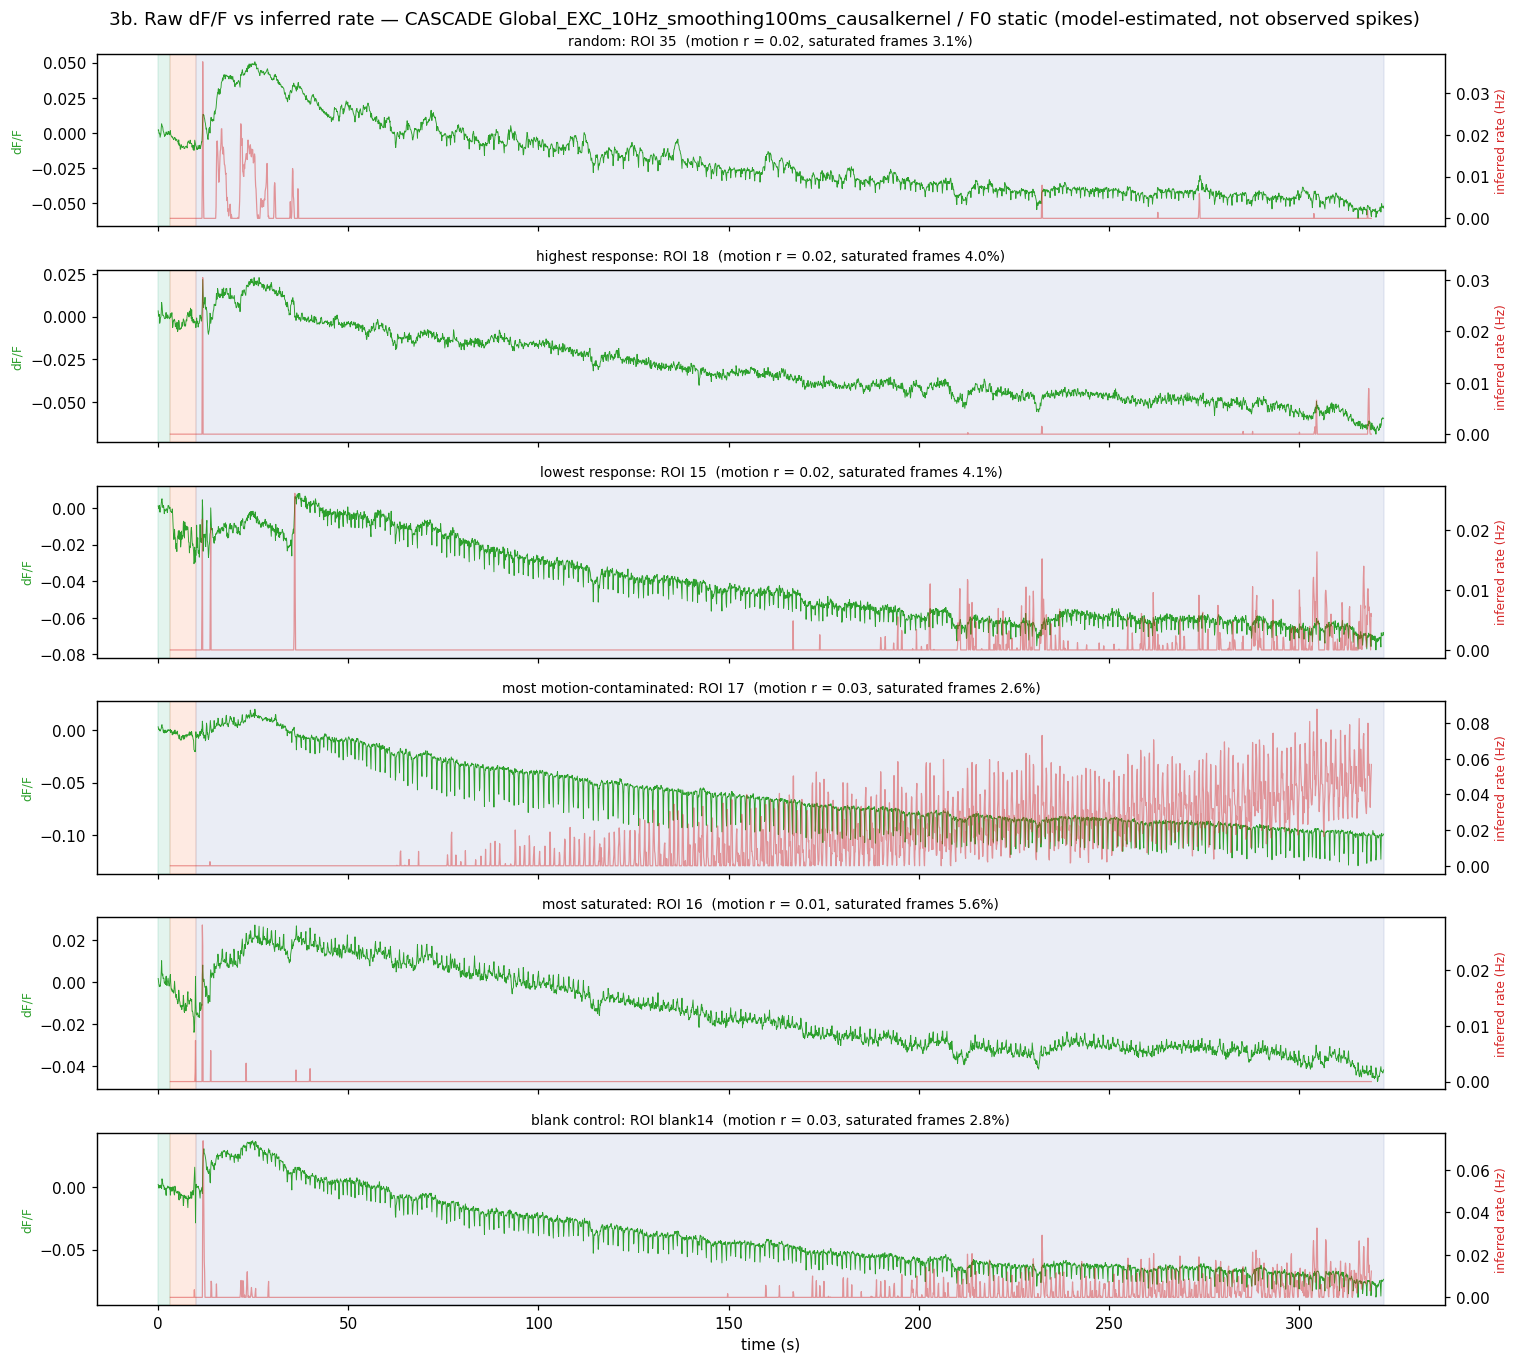

audit ROIs random=35, highest response=18, lowest response=15, most motion-contaminated=17, most saturated=16, blank control=blank14  |  blank controls: mean 0.000 Hz, peak 0.205 Hz inferred


In [20]:
_primary_dff = dff[F0_PRIMARY]
_within = np.any([epoch_masks[e] for e in within_epochs], axis=0)
_base = epoch_masks[baseline_epoch]
_response = _primary_dff[_within].mean(axis=0) - _primary_dff[_base].mean(axis=0)
_motion_r = np.array([abs(pearsonr(_primary_dff[:, j], motion_px)[0]) for j in range(n_roi)])
_saturation = (F_roi >= 0.99 * F_roi.max(axis=0, keepdims=True)).mean(axis=0)
_real = np.flatnonzero(~is_blank)
_blank_rate = np.nanmean(rates[PRIMARY_KEY][is_blank], axis=1)

picks = {
    "random": int(np.random.default_rng(CLUSTER_SEED).choice(_real)),
    "highest response": int(_real[np.argmax(_response[_real])]),
    "lowest response": int(_real[np.argmin(_response[_real])]),
    "most motion-contaminated": int(_real[np.argmax(_motion_r[_real])]),
    "most saturated": int(_real[np.argmax(_saturation[_real])]),
    "blank control": int(np.flatnonzero(is_blank)[np.argmax(_blank_rate)]),
}

fig, axes = plt.subplots(len(picks), 1, figsize=(14, 2.1 * len(picks)), sharex=True)
for ax, (why, j) in zip(axes, picks.items()):
    ax.plot(times_s, _primary_dff[:, j], lw=0.6, color="tab:green")
    ax.set_ylabel("dF/F", color="tab:green", fontsize=8)
    twin = ax.twinx()
    twin.plot(times_s, rates[PRIMARY_KEY][j], lw=0.8, color="tab:red", alpha=0.45)
    twin.set_ylabel("inferred rate (Hz)", color="tab:red", fontsize=8)
    for k, row in epochs.iterrows():
        ax.axvspan(row["t_start_s"], row["t_end_s"], color=plt.cm.Set2(k % 8), alpha=0.18)
    ax.set_title(f"{why}: ROI {roi_labels[j]}  (motion r = {_motion_r[j]:.2f}, "
                 f"saturated frames {100 * _saturation[j]:.1f}%)", fontsize=9)
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"3b. Raw dF/F vs inferred rate — {SPIKE_TAG} (model-estimated, not observed spikes)")
fig.tight_layout()
save_fig(fig, "3b_cascade_audit")
plt.show()

_blank_peak = float(np.nanmax(rates[PRIMARY_KEY][is_blank]))
record("cascade", audit_rois={why: roi_labels[j] for why, j in picks.items()},
       blank_peak_inferred_hz=_blank_peak,
       blank_mean_inferred_hz=float(np.nanmean(rates[PRIMARY_KEY][is_blank])))
print("audit ROIs " + ", ".join(f"{why}={roi_labels[j]}" for why, j in picks.items())
      + f"  |  blank controls: mean {np.nanmean(rates[PRIMARY_KEY][is_blank]):.3f} Hz, peak "
        f"{_blank_peak:.3f} Hz inferred")

## 4. Analysis

### 4a. Feature table

One tidy long row per `mouse × session × FOV × cell × epoch × signal × baseline × model`, so a
later multi-mouse mixed model can consume it unchanged (B Step 2, Step 7). AUC / expected count
are **primary**; peak is secondary because saturation, smoothing and single noisy frames distort
it. Windows are the guarded epoch masks; motion-censored frames are excluded and counted.

In [21]:
FEATURE_UNITS = {
    "mean_value": "dF/F: baseline-subtracted mean (fraction) | CASCADE: mean rate (Hz)",
    "integral": "dF/F: baseline-subtracted AUC (dF/F x s) | CASCADE: expected spike count",
    "peak": "dF/F: peak of the PEAK_SMOOTH_S rolling mean (fraction) | CASCADE: peak smoothed Hz",
    "sustained": "mean over the late half of the epoch, same units as mean_value",
    "baseline_level": "the cell's own baseline-epoch level, per-frame units of the signal",
    "latency_s": "dF/F: first crossing of LATENCY_FRAC x epoch peak | CASCADE: first crossing of "
                 "theta = half the single-spike peak rate; onset criterion only, the trace is "
                 "never thresholded into discrete spikes (C1, A §1.1)",
    "time_to_peak_s": "time from epoch start to the smoothed peak",
    "fwhm_s": "duration above half the epoch peak",
    "decay_tau_s": "mono-exponential decay constant fitted from the peak to the epoch end",
    "early_late_ratio": "mean over the first half / mean over the second half of the epoch",
    "rebound": "mean over REBOUND_S after the epoch, minus the cell's baseline level",
    "motion_px_mean": "mean |registration shift| over the frames used",
}


def _smooth(x: np.ndarray, seconds: float) -> np.ndarray:
    return ndimage.uniform_filter1d(x, size=max(1, round(seconds * fps)), mode="nearest")


def _decay_tau(t: np.ndarray, y: np.ndarray) -> float:
    if t.size < 5 or not np.isfinite(y).all():
        return np.nan
    try:
        with warnings.catch_warnings():                      # a failed fit returns NaN, quietly
            warnings.simplefilter("ignore")
            (_, tau, _), _ = curve_fit(
                lambda x, a, tau, c: a * np.exp(-x / tau) + c, t - t[0], y,
                p0=(max(y[0] - y[-1], 1e-6), max(t[-1] - t[0], 1e-3), y[-1]), maxfev=4000)
        return float(tau) if 0 < tau < 10 * (t[-1] - t[0] + 1e-9) else np.nan
    except Exception:
        return np.nan


def _epoch_features(x: np.ndarray, sel: np.ndarray, base_level: float, theta: float | None) -> dict:
    """Features of one per-frame signal inside one epoch. `x` may contain NaN (CASCADE edges)."""
    used = sel & np.isfinite(x)
    if used.sum() < 3 or not np.isfinite(base_level):
        return {k: np.nan for k in ("mean_value", "integral", "peak", "sustained", "latency_s",
                                    "time_to_peak_s", "fwhm_s", "decay_tau_s", "early_late_ratio")}
    t, w = times_s[used], dt_s[used]
    centred = (x - base_level) if theta is None else x           # dF/F is baseline-subtracted
    y = centred[used]
    ys = _smooth(y, PEAK_SMOOTH_S)
    half = t <= t[0] + (t[-1] - t[0]) / 2
    peak_i = int(np.argmax(ys))
    level = theta if theta is not None else LATENCY_FRAC * ys[peak_i]
    above = np.flatnonzero(ys >= level)
    early, late = float(np.mean(y[half])), float(np.mean(y[~half]))
    return {
        "mean_value": float(np.sum(y * w) / np.sum(w)),
        "integral": float(np.sum(y * w)),
        "peak": float(ys[peak_i]),
        "sustained": late,
        "latency_s": float(t[above[0]] - t[0]) if above.size else np.nan,
        "time_to_peak_s": float(t[peak_i] - t[0]),
        "fwhm_s": float(np.sum(w[ys >= 0.5 * ys[peak_i]])) if ys[peak_i] > 0 else np.nan,
        "decay_tau_s": _decay_tau(t[peak_i:], ys[peak_i:]),
        "early_late_ratio": early / late if abs(late) > 1e-9 else np.nan,
    }


def build_features(masks: dict[str, np.ndarray] | None = None, censor: bool = True) -> pd.DataFrame:
    """The §4a table. `masks`/`censor` are the handles the §A robustness panel varies."""
    masks = epoch_masks if masks is None else masks
    keep = ~motion_censored if censor else np.ones(n_frames, bool)
    meta = epochs.set_index("epoch")
    rebound_masks = {e: (times_s > meta.loc[e, "t_end_s"]) &
                        (times_s <= meta.loc[e, "t_end_s"] + REBOUND_S) for e in masks}
    out = []
    for model, baseline in itertools.product(CASCADE_MODELS, (F0_PRIMARY, F0_SENSITIVITY)):
        theta_hz = 0.5 / (model_specs[model]["smoothing_s"] * np.sqrt(2 * np.pi))
        signals = {"dff": (dff[baseline].T, None), "cascade": (rates[(model, baseline)], theta_hz)}
        for signal, (X, theta) in signals.items():
            base_sel = masks[baseline_epoch] & keep
            with warnings.catch_warnings():        # an all-NaN baseline is reported in §3, not here
                warnings.simplefilter("ignore")
                base_level = np.array([np.nanmean(np.where(base_sel & np.isfinite(X[j]), X[j], np.nan))
                                       for j in range(n_roi)])
            for epoch, mask in masks.items():
                sel = mask & keep
                for j in range(n_roi):
                    feats = _epoch_features(X[j], sel, base_level[j], theta)
                    reb = np.where(rebound_masks[epoch] & np.isfinite(X[j]), X[j], np.nan)
                    used = sel & np.isfinite(X[j])
                    out.append({
                        "mouse_id": MOUSE_ID, "session_id": SESSION_ID, "fov_id": FOV_ID,
                        "roi": roi_labels[j], "is_blank": bool(is_blank[j]),
                        "epoch": epoch, "role": meta.loc[epoch, "role"],
                        "signal": signal, "baseline": baseline, "model": model,
                        **feats,
                        "baseline_level": float(base_level[j]),
                        "rebound": float(np.nanmean(reb) - base_level[j]) if np.isfinite(reb).any()
                                   else np.nan,
                        "motion_px_mean": float(motion_px[used].mean()) if used.any() else np.nan,
                        "n_frames_used": int(used.sum()),
                        "n_frames_censored": int((mask & ~keep).sum()),
                        "n_frames_total": int(mask.sum()),
                        "trial": 1,
                    })
    return pd.DataFrame(out)


features = build_features()
features.to_csv(OUTPUT_DIR / "features.csv", index=False)
expected_rows = n_roi * len(epochs) * 2 * 2 * len(CASCADE_MODELS)
assert len(features) == expected_rows, f"{len(features)} rows, expected {expected_rows}"
record("features", file=str(OUTPUT_DIR / "features.csv"), n_rows=len(features),
       row_key="mouse x session x FOV x cell x epoch x signal x baseline x model",
       units=FEATURE_UNITS, peak_smooth_s=PEAK_SMOOTH_S, latency_frac=LATENCY_FRAC,
       rebound_s=REBOUND_S, primary_features=["integral", "mean_value"],
       secondary_features=["peak", "sustained", "latency_s", "time_to_peak_s", "fwhm_s",
                           "decay_tau_s", "early_late_ratio", "rebound"],
       note="dF/F rows are identical across models by construction; the model column is carried so "
            "every dF/F row has a matched CASCADE row (C4)")
display(features.head(4))
print(f"features.csv: {len(features)} rows = {n_roi} ROI x {len(epochs)} epochs x 2 signals x "
      f"2 baselines x {len(CASCADE_MODELS)} models  |  N mice 1 / sessions 1 / FOVs 1 / cells "
      f"{n_real} real + {n_blank} blank / trials 1")

,mouse_id,session_id,fov_id,roi,is_blank,epoch,role,signal,baseline,model,...,fwhm_s,decay_tau_s,early_late_ratio,baseline_level,rebound,motion_px_mean,n_frames_used,n_frames_censored,n_frames_total,trial
0,leftDRGcut,leftDRGcut-1,FOV1,1,False,before,before,dff,static,Global_EXC_10Hz_smoothing100ms_causalkernel,...,0.4010,0.472049,-1.0,0.000435,-0.006273,0.0,18,0,18,1
1,leftDRGcut,leftDRGcut-1,FOV1,2,False,before,before,dff,static,Global_EXC_10Hz_smoothing100ms_causalkernel,...,0.4010,5.577197,-1.0,0.000344,-0.008808,0.0,18,0,18,1
2,leftDRGcut,leftDRGcut-1,FOV1,3,False,before,before,dff,static,Global_EXC_10Hz_smoothing100ms_causalkernel,...,0.4010,0.722841,-1.0,0.000742,-0.008137,0.0,18,0,18,1
3,leftDRGcut,leftDRGcut-1,FOV1,4,False,before,before,dff,static,Global_EXC_10Hz_smoothing100ms_causalkernel,...,0.4005,0.387411,-1.0,0.000926,-0.007200,0.0,18,0,18,1


features.csv: 1440 rows = 60 ROI x 3 epochs x 2 signals x 2 baselines x 2 models  |  N mice 1 / sessions 1 / FOVs 1 / cells 40 real + 20 blank / trials 1


### 4b. Responders against an empirical null

The stimulus times are circularly shifted, which keeps each trace's autocorrelation intact; the
same window statistic is recomputed on every shift, `p = (b+1)/(B+1)`, then Benjamini–Hochberg
across the ROI × epoch × direction family (B Step 8). Shifts are **restricted to stimulus-free
placements** — a surrogate window that still straddles the real stimulus inherits the response it
is meant to test against (B Step 8.1), which caps `B` at the number of such placements and sets a
floor on the resolvable p. The minimum effect size is **calibrated on this dataset's blank ROIs**,
not copied from the literature (A §2 Step 3) — which also means the blank false-positive rate is
bounded by `100 − BLANK_CALIB_PCT` by construction: read it against the real responder fraction.

In [22]:
def window_stats(X: np.ndarray, masks: dict[str, np.ndarray], shift: int = 0) -> np.ndarray:
    """(n_epoch, n_roi) baseline-subtracted integrals, with the whole epoch set shifted by `shift`.

    Weighted by bin width and by finiteness, so censored and CASCADE-NaN bins simply do not
    contribute (C2). `shift` circularly moves every declared window together — the stimulus moves,
    the trace does not (B Step 8.1).
    """
    finite = np.isfinite(X).astype(np.float64)                      # (n_roi, n_frames)
    filled = np.nan_to_num(X, nan=0.0)
    W = np.stack([np.roll(masks[e] & ~motion_censored, shift) * dt_s for e in masks])
    duration = W @ finite.T                                         # (n_epoch, n_roi)
    total = W @ filled.T
    with np.errstate(invalid="ignore", divide="ignore"):
        means = np.where(duration > 0, total / duration, np.nan)
    base = means[list(masks).index(baseline_epoch)]
    return (means - base) * duration


def bh_fdr(p: np.ndarray, q: float) -> np.ndarray:
    """Benjamini–Hochberg rejection mask over a flat family of p-values."""
    flat = p.ravel()
    order = np.argsort(flat)
    thresh = q * (np.arange(1, flat.size + 1) / flat.size)
    passed = flat[order] <= thresh
    cutoff = np.max(np.flatnonzero(passed)) if passed.any() else -1
    out = np.zeros(flat.size, bool)
    out[order[:cutoff + 1]] = True
    return out.reshape(p.shape)


def surrogate_seed(key: str) -> int:
    """Stable per-signal seed — `hash()` is salted per process, so it cannot be recorded."""
    return int(hashlib.md5(key.encode()).hexdigest()[:8], 16)


def stimulus_free_shifts() -> np.ndarray:
    """Circular shifts whose displaced stimulus window (plus its guard tail) misses the real one.

    A surrogate that still straddles the real stimulus inherits the very response it is meant to
    test against, and those placements dominate the upper tail of the null — which is why B Step 8.1
    asks for pseudo-onsets drawn from stimulus-free periods.
    """
    stim = (times_s >= STIM_ONSET_S - guard_s) & (times_s <= STIM_OFFSET_S + guard_s)
    ok = np.array([k for k in range(1, n_frames) if not (np.roll(stim, k) & stim).any()])
    if ok.size == 0:
        raise ValueError("no stimulus-free placement exists for the declared stimulus window — it "
                         "covers more than half the recording, so a circular-shift null cannot be "
                         "built (B Step 8.1). Use matched unstimulated recordings instead.")
    return ok


SHIFT_POOL = stimulus_free_shifts()
N_SURR = int(min(N_SURROGATES, SHIFT_POOL.size))       # B is capped by the placements that exist
P_FLOOR = 1 / (N_SURR + 1)


def surrogate_null(X: np.ndarray, key: str) -> np.ndarray:
    """(N_SURR, n_epoch, n_roi) window statistics under stimulus-free pseudo-onsets."""
    seed = surrogate_seed(key)

    def build():
        rng = np.random.default_rng(seed)
        shifts_ = rng.choice(SHIFT_POOL, size=N_SURR, replace=False)
        return {"null": np.stack([window_stats(X, epoch_masks, int(s))
                                  for s in tqdm(shifts_, desc=f"surrogates {key}")])}
    return cached(CACHE_DIR / f"null_{digest(X, key, seed, N_SURR, SHIFT_POOL, list(epoch_masks))}.npz",
                  build)["null"]


tested = [e for e in epoch_masks if e != baseline_epoch]
resp_rows = []
for model, baseline in itertools.product(CASCADE_MODELS, (F0_PRIMARY, F0_SENSITIVITY)):
    for signal, X in (("dff", dff[baseline].T), ("cascade", rates[(model, baseline)])):
        key = f"{signal}|{baseline}|{model}"
        obs = window_stats(X, epoch_masks)
        null = surrogate_null(X, key)
        keep_e = [list(epoch_masks).index(e) for e in tested]
        obs_t, null_t = obs[keep_e], null[:, keep_e]
        p_high = (np.sum(null_t >= obs_t, axis=0) + 1) / (N_SURR + 1)
        p_low = (np.sum(null_t <= obs_t, axis=0) + 1) / (N_SURR + 1)
        z = (obs_t - null_t.mean(axis=0)) / np.where(null_t.std(axis=0) > 0, null_t.std(axis=0), np.nan)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")        # all-NaN when CASCADE never covered the window
            min_effect = MIN_EFFECT_SCALE * float(np.nanpercentile(np.abs(z[:, is_blank]),
                                                                   BLANK_CALIB_PCT))
        rej = bh_fdr(np.concatenate([p_high, p_low]), FDR_Q).reshape(2, *p_high.shape)
        for e_i, epoch in enumerate(tested):
            for j in range(n_roi):
                resp_rows.append({
                    "signal": signal, "baseline": baseline, "model": model, "epoch": epoch,
                    "roi": roi_labels[j], "is_blank": bool(is_blank[j]),
                    "statistic": float(obs_t[e_i, j]), "effect_z": float(z[e_i, j]),
                    "p_high": float(p_high[e_i, j]), "p_low": float(p_low[e_i, j]),
                    "min_effect_z": min_effect,
                    "excited": bool(rej[0, e_i, j] and z[e_i, j] >= min_effect),
                    "inhibited": bool(rej[1, e_i, j] and -z[e_i, j] >= min_effect),
                })

responses = pd.DataFrame(resp_rows)


def classify(sub: pd.DataFrame) -> dict:
    """Response pattern from the per-epoch flags. Order matters: first matching rule wins."""
    hi = set(sub.loc[sub["excited"], "epoch"]); lo = set(sub.loc[sub["inhibited"], "epoch"])
    hit = hi | lo
    direction = ("mixed" if (hi & set(within_epochs)) and (lo & set(within_epochs)) else
                 "excited" if hi & set(within_epochs) else
                 "inhibited" if lo & set(within_epochs) else
                 "excited" if hi else "inhibited" if lo else "none")
    if not hit:
        pattern = "nonresponsive"
    elif after_epochs and after_epochs[-1] in hit:
        pattern = "delayed_persistent"
    elif within_epochs and within_epochs[-1] in hit:
        pattern = "sustained"
    elif within_epochs and within_epochs[0] in hit:
        pattern = "onset_only"
    elif after_epochs and after_epochs[0] in hit:
        pattern = "offset_rebound"
    else:
        pattern = "other"
    return {"direction": direction, "pattern": pattern, "n_epochs_flagged": len(hit)}


phenotypes = pd.DataFrame([
    dict(zip(("signal", "baseline", "model", "roi", "is_blank"), keys)) | classify(sub)
    for keys, sub in responses.groupby(["signal", "baseline", "model", "roi", "is_blank"])
])
responses.to_csv(OUTPUT_DIR / "responses.csv", index=False)
phenotypes.to_csv(OUTPUT_DIR / "phenotypes.csv", index=False)

flagged = responses["excited"] | responses["inhibited"]
blank_fpr = float(flagged[responses["is_blank"]].mean())
primary_pheno = phenotypes[(~phenotypes["is_blank"]) &                 # both signals, primary run
                           (phenotypes["model"] == PRIMARY_KEY[0]) &
                           (phenotypes["baseline"] == PRIMARY_KEY[1])]
real_frac = float(primary_pheno.loc[primary_pheno["signal"] == "cascade", "pattern"]
                  .ne("nonresponsive").mean())
n_tests = 2 * len(tested) * n_roi                      # the BH family, per (signal, baseline, model)
ties_needed = int(np.ceil(P_FLOOR * n_tests / FDR_Q))  # how many tests must reach the floor to pass
record("responders", n_surrogates_requested=N_SURROGATES, n_surrogates_used=N_SURR,
       n_stimulus_free_shifts=int(SHIFT_POOL.size), p_floor=P_FLOOR, fdr_q=FDR_Q,
       multiplicity_family="ROI x epoch x direction, within each (signal, baseline, model)",
       surrogate="circular shift of all declared windows together, restricted to placements whose "
                 "stimulus window plus guard tail does not overlap the real one (B Step 8.1)",
       surrogate_seeds={k: surrogate_seed(k) for k in
                        [f"{s}|{b}|{m}" for m, b in itertools.product(
                            CASCADE_MODELS, (F0_PRIMARY, F0_SENSITIVITY))
                         for s in ("dff", "cascade")]},
       min_effect_rule=f"{BLANK_CALIB_PCT}th percentile of |z| over blank ROIs x "
                       f"{MIN_EFFECT_SCALE}", blank_false_positive_rate=blank_fpr,
       responder_fraction_primary=real_frac, files=["responses.csv", "phenotypes.csv"])
display(phenotypes[(phenotypes["signal"] == "cascade") & (phenotypes["model"] == PRIMARY_KEY[0]) &
                   (phenotypes["baseline"] == PRIMARY_KEY[1])]
        .groupby(["is_blank", "pattern"]).size().rename("n_cells").reset_index())
if blank_fpr > FDR_Q:
    print(f"! WARNING blank-ROI false-positive rate {blank_fpr:.3f} exceeds FDR_Q = {FDR_Q} — the "
          "null is not calibrated on this dataset; treat every responder count below as suspect "
          "(A §2 Step 3).")
print(f"blank-ROI false-positive rate {blank_fpr:.3f} (over {int(responses['is_blank'].sum())} "
      f"blank tests; the effect-size floor puts a ~{(100 - BLANK_CALIB_PCT) / 100:.2f} bound there "
      f"by construction, so read it against the real fraction, not as an absolute error rate) "
      f"vs responder fraction {real_frac:.2f} of {n_real} real ROIs "
      f"[{SPIKE_TAG}]  |  B = {N_SURR} of {N_SURROGATES} requested "
      f"({SHIFT_POOL.size} stimulus-free placements exist), finest p = {P_FLOOR:.4f}, so BH at "
      f"q = {FDR_Q} over {n_tests} tests needs >= {ties_needed} of them at that floor  |  "
      f"N mice 1 / sessions 1 / FOVs 1 / trials 1")

surrogates dff|static|Global_EXC_10Hz_smoothing100ms_causalkernel:   0%|          | 0/1999 [00:00<?, ?it/s]

surrogates cascade|static|Global_EXC_10Hz_smoothing100ms_causalkernel:   0%|          | 0/1999 [00:00<?, ?it/s…

surrogates dff|rolling|Global_EXC_10Hz_smoothing100ms_causalkernel:   0%|          | 0/1999 [00:00<?, ?it/s]

surrogates cascade|rolling|Global_EXC_10Hz_smoothing100ms_causalkernel:   0%|          | 0/1999 [00:00<?, ?it/…

surrogates dff|static|Spinal_cord_excitatory_30Hz_smoothing50ms:   0%|          | 0/1999 [00:00<?, ?it/s]

surrogates cascade|static|Spinal_cord_excitatory_30Hz_smoothing50ms:   0%|          | 0/1999 [00:00<?, ?it/s]

surrogates dff|rolling|Spinal_cord_excitatory_30Hz_smoothing50ms:   0%|          | 0/1999 [00:00<?, ?it/s]

surrogates cascade|rolling|Spinal_cord_excitatory_30Hz_smoothing50ms:   0%|          | 0/1999 [00:00<?, ?it/s]

,is_blank,pattern,n_cells
0,False,nonresponsive,40
1,True,nonresponsive,20


blank-ROI false-positive rate 0.013 (over 320 blank tests; the effect-size floor puts a ~0.05 bound there by construction, so read it against the real fraction, not as an absolute error rate) vs responder fraction 0.00 of 40 real ROIs [CASCADE Global_EXC_10Hz_smoothing100ms_causalkernel / F0 static]  |  B = 1999 of 1999 requested (3031 stimulus-free placements exist), finest p = 0.0005, so BH at q = 0.05 over 240 tests needs >= 3 of them at that floor  |  N mice 1 / sessions 1 / FOVs 1 / trials 1


### 4c. Epoch contrasts — descriptive, single animal

Each epoch against the declared baseline epoch, on both signals, both baselines and every model
(C4). With `N mice = 1` no valid cross-animal p-value exists, so this reports **effect sizes with
hierarchical-bootstrap intervals over cell → trial** and nothing else (B Step 9, A §1.4). The
emitted table is shaped for a later multi-mouse mixed model — `response ~ condition * epoch +
(1 + epoch | mouse) + …` — to consume unchanged.

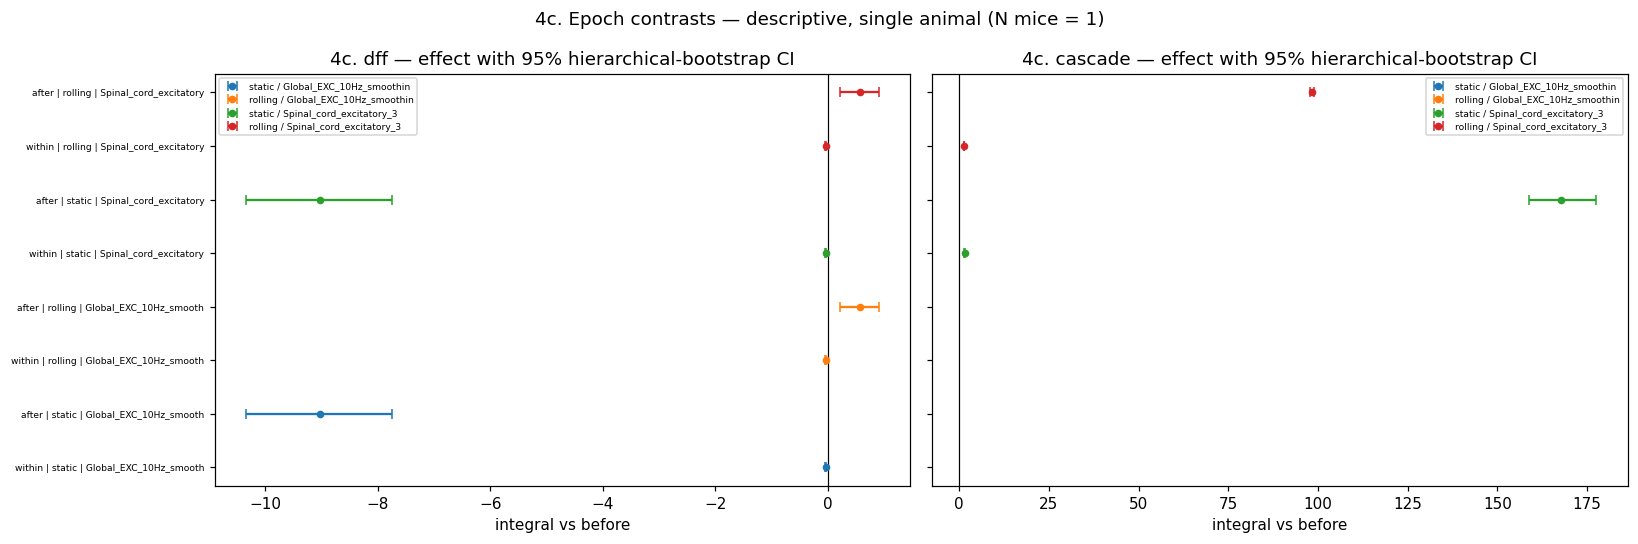

,signal,baseline,model,effect,ci_lo,ci_hi,n_cells,unit
0,dff,static,Global_EXC_10Hz_smoothing100ms_causalkernel,-0.0414,-0.0446,-0.0381,40,dF/F: baseline-subtracted AUC (dF/F x s)
2,cascade,static,Global_EXC_10Hz_smoothing100ms_causalkernel,NaN,NaN,NaN,0,CASCADE: expected spike count
4,dff,rolling,Global_EXC_10Hz_smoothing100ms_causalkernel,-0.0413,-0.0445,-0.0381,40,dF/F: baseline-subtracted AUC (dF/F x s)
6,cascade,rolling,Global_EXC_10Hz_smoothing100ms_causalkernel,NaN,NaN,NaN,0,CASCADE: expected spike count
8,dff,static,Spinal_cord_excitatory_30Hz_smoothing50ms,-0.0414,-0.0446,-0.0381,40,dF/F: baseline-subtracted AUC (dF/F x s)
10,cascade,static,Spinal_cord_excitatory_30Hz_smoothing50ms,1.4833,1.4657,1.5014,40,CASCADE: expected spike count
12,dff,rolling,Spinal_cord_excitatory_30Hz_smoothing50ms,-0.0413,-0.0445,-0.0381,40,dF/F: baseline-subtracted AUC (dF/F x s)
14,cascade,rolling,Spinal_cord_excitatory_30Hz_smoothing50ms,1.3363,1.3308,1.3419,40,CASCADE: expected spike count


64 contrasts written  |  headline = integral in within vs before  |  every row carries a 95% CI  |  N mice 1 / sessions 1 / FOVs 1 / cells 40 real + 20 blank / trials 1


In [23]:
def hierarchical_bootstrap(values: np.ndarray, n_boot: int = N_BOOT, seed: int = 0) -> tuple:
    """Resample cells with replacement, then trials within cell (degenerate here: 1 trial).

    Returns (point estimate, lo, hi) for the mean, as a 95% percentile interval.
    """
    v = values[np.isfinite(values)]
    if v.size < 2:
        return float(np.mean(v)) if v.size else np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = v[rng.integers(0, v.size, size=(n_boot, v.size))].mean(axis=1)
    return float(v.mean()), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


def cell_deltas(feat: pd.DataFrame, feature: str, epoch: str, signal: str, baseline: str,
                model: str, blank: bool) -> np.ndarray:
    """Per-cell (epoch − baseline epoch) difference for one feature and one analysis combination."""
    sub = feat[(feat["signal"] == signal) & (feat["baseline"] == baseline) &
               (feat["model"] == model) & (feat["is_blank"] == blank)]
    piv = sub.pivot(index="roi", columns="epoch", values=feature)
    return (piv[epoch] - piv[baseline_epoch]).to_numpy(dtype=float)


contrast_rows = []
for feature, epoch in itertools.product(("integral", "mean_value"), tested):
    for model, baseline in itertools.product(CASCADE_MODELS, (F0_PRIMARY, F0_SENSITIVITY)):
        for signal, blank in itertools.product(("dff", "cascade"), (False, True)):
            delta = cell_deltas(features, feature, epoch, signal, baseline, model, blank)
            est, lo, hi = hierarchical_bootstrap(delta, seed=CLUSTER_SEED)
            contrast_rows.append({
                "mouse_id": MOUSE_ID, "session_id": SESSION_ID, "fov_id": FOV_ID,
                "feature": feature, "epoch": epoch, "vs": baseline_epoch, "signal": signal,
                "baseline": baseline, "model": model, "roi_set": "blank" if blank else "real",
                "n_cells": int(np.isfinite(delta).sum()), "n_trials": 1,
                "effect": est, "ci_lo": lo, "ci_hi": hi,
                "unit": FEATURE_UNITS[feature].split("|")[0 if signal == "dff" else 1].strip(),
            })

contrasts = pd.DataFrame(contrast_rows)
contrasts.to_csv(OUTPUT_DIR / "contrasts.csv", index=False)
HEADLINE = {"feature": "integral", "epoch": within_epochs[-1] if within_epochs else tested[-1]}
headline = contrasts[(contrasts["feature"] == HEADLINE["feature"]) &
                     (contrasts["epoch"] == HEADLINE["epoch"]) & (contrasts["roi_set"] == "real")]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
combos = list(itertools.product(CASCADE_MODELS, (F0_PRIMARY, F0_SENSITIVITY)))
ticks = [f"{e} | {b} | {m[:22]}" for m, b in combos for e in tested]
for ax, signal in zip(axes, ("dff", "cascade")):
    sub = contrasts[(contrasts["feature"] == "integral") & (contrasts["roi_set"] == "real") &
                    (contrasts["signal"] == signal)]
    for c, (model, baseline) in enumerate(combos):
        part = (sub[(sub["model"] == model) & (sub["baseline"] == baseline)]
                .set_index("epoch").loc[tested])
        y = np.arange(len(tested)) + c * len(tested)
        ax.errorbar(part["effect"], y,
                    xerr=[part["effect"] - part["ci_lo"], part["ci_hi"] - part["effect"]],
                    fmt="o", capsize=3, ms=4, color=plt.cm.tab10(c),
                    label=f"{baseline} / {model[:24]}")
    ax.axvline(0, color="k", lw=0.8)
    ax.set_yticks(range(len(ticks))); ax.set_yticklabels(ticks, fontsize=6)
    ax.set_xlabel(f"integral vs {baseline_epoch}")
    ax.set_title(f"4c. {signal} — effect with 95% hierarchical-bootstrap CI")
    ax.legend(fontsize=6)
fig.suptitle("4c. Epoch contrasts — descriptive, single animal (N mice = 1)")
fig.tight_layout()
save_fig(fig, "4c_epoch_contrasts")
plt.show()

record("contrasts", file=str(OUTPUT_DIR / "contrasts.csv"), headline=HEADLINE,
       estimator="mean of per-cell (epoch - baseline epoch) differences",
       interval="95% percentile hierarchical bootstrap, cell -> trial",
       n_boot=N_BOOT, seed=CLUSTER_SEED, inference="descriptive, single animal; no p-values")
display(headline[["signal", "baseline", "model", "effect", "ci_lo", "ci_hi", "n_cells", "unit"]]
        .round(4))
print(f"{len(contrasts)} contrasts written  |  headline = {HEADLINE['feature']} in "
      f"{HEADLINE['epoch']} vs {baseline_epoch}  |  every row carries a 95% CI  |  "
      f"N mice 1 / sessions 1 / FOVs 1 / cells {n_real} real + {n_blank} blank / trials 1")

### 4d. Population structure — correlation

The same ROI×ROI Pearson matrix on raw dF/F and on inferred rate, natural ROI order in both so the
panels are comparable cell by cell. Time bins that are not finite for every ROI are dropped
(CASCADE edge padding). Pairwise correlations are among the quantities *most* changed by the
deconvolution choice, which is why both are shown (A §2 Step 5).

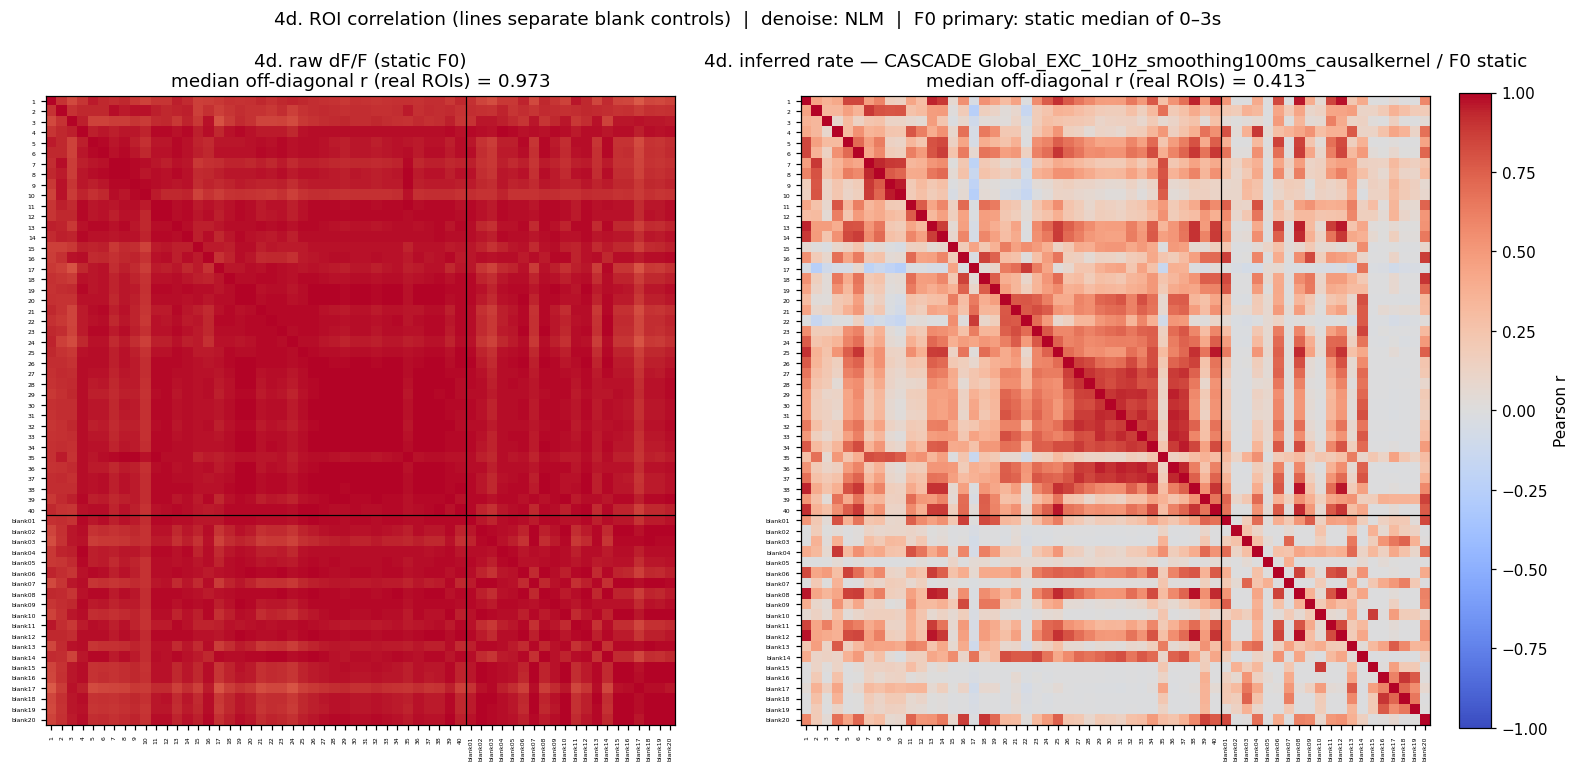

dff: median r real +0.973, blank +0.974  |  cascade: median r real +0.413, blank +0.144  |  780 real ROI pairs  |  N mice 1 / sessions 1 / FOVs 1 / cells 40 real + 20 blank / trials 1


In [24]:
def roi_corr(X: np.ndarray) -> np.ndarray:
    """ROI x ROI Pearson correlation from an (n_roi, n_time) matrix, finite bins only."""
    return np.corrcoef(X[:, np.isfinite(X).all(axis=0)])


def plot_corr(ax, matrix: np.ndarray, title: str):
    im = ax.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.axhline(n_real - 0.5, color="k", lw=0.8); ax.axvline(n_real - 0.5, color="k", lw=0.8)
    ax.set_xticks(range(n_roi)); ax.set_xticklabels(roi_labels, fontsize=4, rotation=90)
    ax.set_yticks(range(n_roi)); ax.set_yticklabels(roi_labels, fontsize=4)
    ax.set_title(f"{title}\nmedian off-diagonal r (real ROIs) = "
                 f"{np.median(offdiag(matrix[:n_real, :n_real])):.3f}")
    return im


corr = {"dff": roi_corr(dff[F0_PRIMARY].T), "cascade": roi_corr(rates[PRIMARY_KEY])}
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
plot_corr(axes[0], corr["dff"], f"4d. raw dF/F ({F0_PRIMARY} F0)")
im = plot_corr(axes[1], corr["cascade"], f"4d. inferred rate — {SPIKE_TAG}")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="Pearson r")
fig.suptitle(f"4d. ROI correlation (lines separate blank controls)  |  {METHOD_TAG}")
save_fig(fig, "4d_correlation")
plt.show()

record("population", correlation_median_r={k: float(np.median(offdiag(v[:n_real, :n_real])))
                                           for k, v in corr.items()},
       correlation_median_r_blank={k: float(np.median(offdiag(v[n_real:, n_real:])))
                                   for k, v in corr.items()})
print("  |  ".join(f"{k}: median r real {np.median(offdiag(v[:n_real, :n_real])):+.3f}, "
                   f"blank {np.median(offdiag(v[n_real:, n_real:])):+.3f}" for k, v in corr.items())
      + f"  |  {n_real * (n_real - 1) // 2} real ROI pairs  |  N mice 1 / sessions 1 / FOVs 1 / "
        f"cells {n_real} real + {n_blank} blank / trials 1")

### 4d (cont). How many clusters? — you choose, nothing is selected for you

Performance across `PCA_K_GRID` at the CONFIG `PCA_N_COMPONENTS`: silhouette, within- vs
between-cluster trace coherence, smallest cluster, and leave-one-epoch-out stability. **The argmax
is deliberately not taken** — selecting k on the same data used to report the clustering is
post-selection inference (A §1.5, B §2.1 Chen et al.). Read the curve, then type a k in the box
(positive integer ≥ 2); the box defaults to `PCA_K` so a headless run still completes.

/Users/samsonho/exit()/envs/Cajal/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (10) found smaller than n_clusters (11). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/samsonho/exit()/envs/Cajal/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (12). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


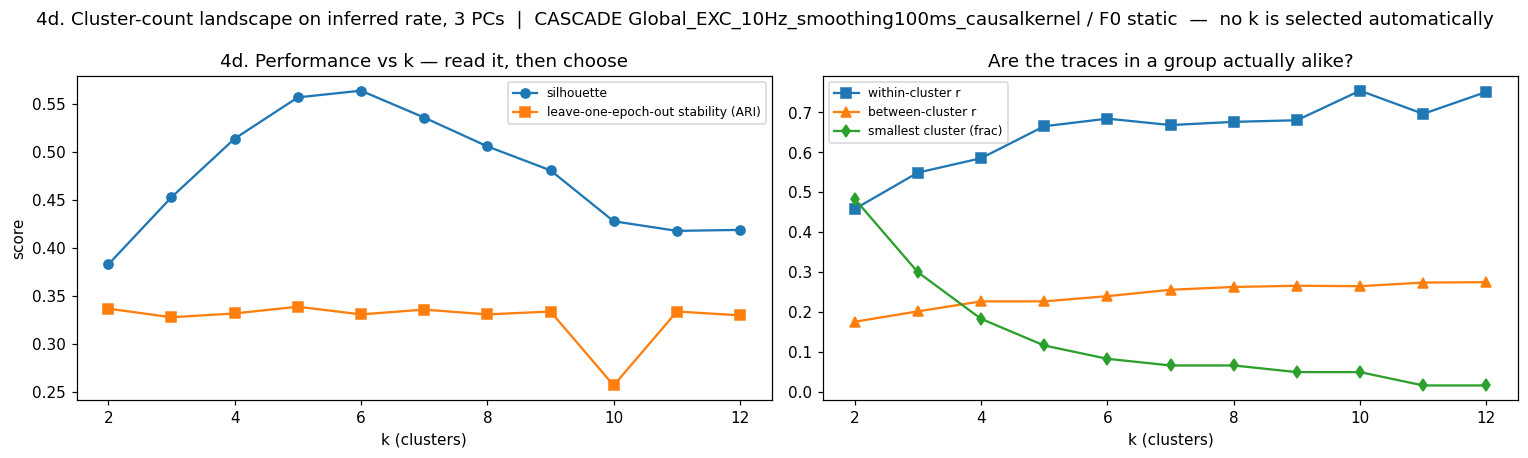

BoundedIntText(value=3, description='k (clusters):', max=59, min=2, style=DescriptionStyle(description_width='…

,k,silhouette,within_r,between_r,separation,smallest_cluster,stability_ari
0,2,0.383,0.458,0.176,0.282,29,0.337
1,3,0.453,0.549,0.202,0.347,18,0.328
2,4,0.514,0.585,0.227,0.358,11,0.332
3,5,0.557,0.665,0.227,0.439,7,0.339
4,6,0.564,0.684,0.240,0.444,5,0.331
5,7,0.536,0.668,0.256,0.412,4,0.336
6,8,0.506,0.676,0.263,0.414,4,0.331
7,9,0.481,0.680,0.266,0.414,3,0.334
8,10,0.428,0.754,0.265,0.489,3,0.257
9,11,0.418,0.696,0.274,0.422,1,0.334


choose k in the box above (integer 2–59), then run the next cell. Default = PCA_K = 3 from CONFIG; nothing here takes an argmax (T11).


In [25]:
def cluster_once(X: np.ndarray, k: int, seed: int = CLUSTER_SEED) -> tuple[np.ndarray, np.ndarray]:
    """z-score -> PCA -> k-means, all fitted on exactly the columns handed in (C8: visualisation)."""
    sd = X.std(axis=1, keepdims=True)
    Z = (X - X.mean(axis=1, keepdims=True)) / np.where(sd > 0, sd, 1.0)
    emb = PCA(n_components=min(PCA_N_COMPONENTS, *Z.shape), random_state=seed).fit_transform(Z)
    return KMeans(n_clusters=k, n_init=50, random_state=seed).fit_predict(emb), emb


def fold_stability(X_all: np.ndarray, finite: np.ndarray, k: int) -> tuple[float, list]:
    """Mean pairwise ARI between labels fitted on leave-one-epoch-out folds (B Step 11.3, 11.7)."""
    labels = []
    for held_out in epoch_masks:
        train = finite & ~epoch_masks[held_out] & ~motion_censored
        if train.sum() > PCA_N_COMPONENTS + 1:
            labels.append(cluster_once(X_all[:, train], k)[0])
    pairs = [adjusted_rand_score(a, b) for a, b in itertools.combinations(labels, 2)]
    return (float(np.mean(pairs)) if pairs else np.nan), labels


def k_scan(X_all: np.ndarray, corr_m: np.ndarray) -> pd.DataFrame:
    """Performance per k. Reported as a landscape — no row here is chosen automatically."""
    finite = np.isfinite(X_all).all(axis=0)
    X = X_all[:, finite]
    rows = []
    for k in PCA_K_GRID:
        if not 2 <= k < X.shape[0]:
            continue
        labels, emb = cluster_once(X, k)
        i, j = np.triu_indices(len(labels), 1)
        same, r = labels[i] == labels[j], corr_m[i, j]
        rows.append({"k": k, "silhouette": round(float(silhouette_score(emb, labels)), 3),
                     "within_r": round(float(r[same].mean()), 3),
                     "between_r": round(float(r[~same].mean()), 3),
                     "separation": round(float(r[same].mean() - r[~same].mean()), 3),
                     "smallest_cluster": int(np.bincount(labels).min()),
                     "stability_ari": round(fold_stability(X_all, finite, k)[0], 3)})
    return pd.DataFrame(rows)


k_table = k_scan(rates[PRIMARY_KEY], corr["cascade"])
fig, (ax_s, ax_r) = plt.subplots(1, 2, figsize=(14, 4.2), sharex=True)
ax_s.plot(k_table["k"], k_table["silhouette"], "o-", label="silhouette")
ax_s.plot(k_table["k"], k_table["stability_ari"], "s-", label="leave-one-epoch-out stability (ARI)")
ax_s.set_xlabel("k (clusters)"); ax_s.set_ylabel("score"); ax_s.legend(fontsize=8)
ax_s.set_title("4d. Performance vs k — read it, then choose")
ax_r.plot(k_table["k"], k_table["within_r"], "s-", label="within-cluster r")
ax_r.plot(k_table["k"], k_table["between_r"], "^-", label="between-cluster r")
ax_r.plot(k_table["k"], k_table["smallest_cluster"] / n_roi, "d-", label="smallest cluster (frac)")
ax_r.set_xlabel("k (clusters)"); ax_r.legend(fontsize=8)
ax_r.set_title("Are the traces in a group actually alike?")
fig.suptitle(f"4d. Cluster-count landscape on inferred rate, {PCA_N_COMPONENTS} PCs  |  {SPIKE_TAG}"
             "  —  no k is selected automatically")
fig.tight_layout()
save_fig(fig, "4d_k_landscape")
plt.show()

k_input = widgets.BoundedIntText(value=int(PCA_K), min=2, max=max(2, n_roi - 1), step=1,
                                 description="k (clusters):", continuous_update=False,
                                 style={"description_width": "initial"})
display(k_input)
display(k_table)
print(f"choose k in the box above (integer 2–{max(2, n_roi - 1)}), then run the next cell. "
      f"Default = PCA_K = {PCA_K} from CONFIG; nothing here takes an argmax (T11).")

### 4d (cont). Clusters at the chosen k, without leakage

Reads `k_input.value`, so whatever you typed above is what gets fitted; on a fresh kernel it falls
back to `PCA_K`. Normalisation and PCA are fitted **inside each fold**, and folds are whole epochs,
never random frames (B Step 11). Groups are called **clusters**: naming a phenotype needs stability
plus held-out confirmation, so the stability score and its label-shuffle p sit on the figure.

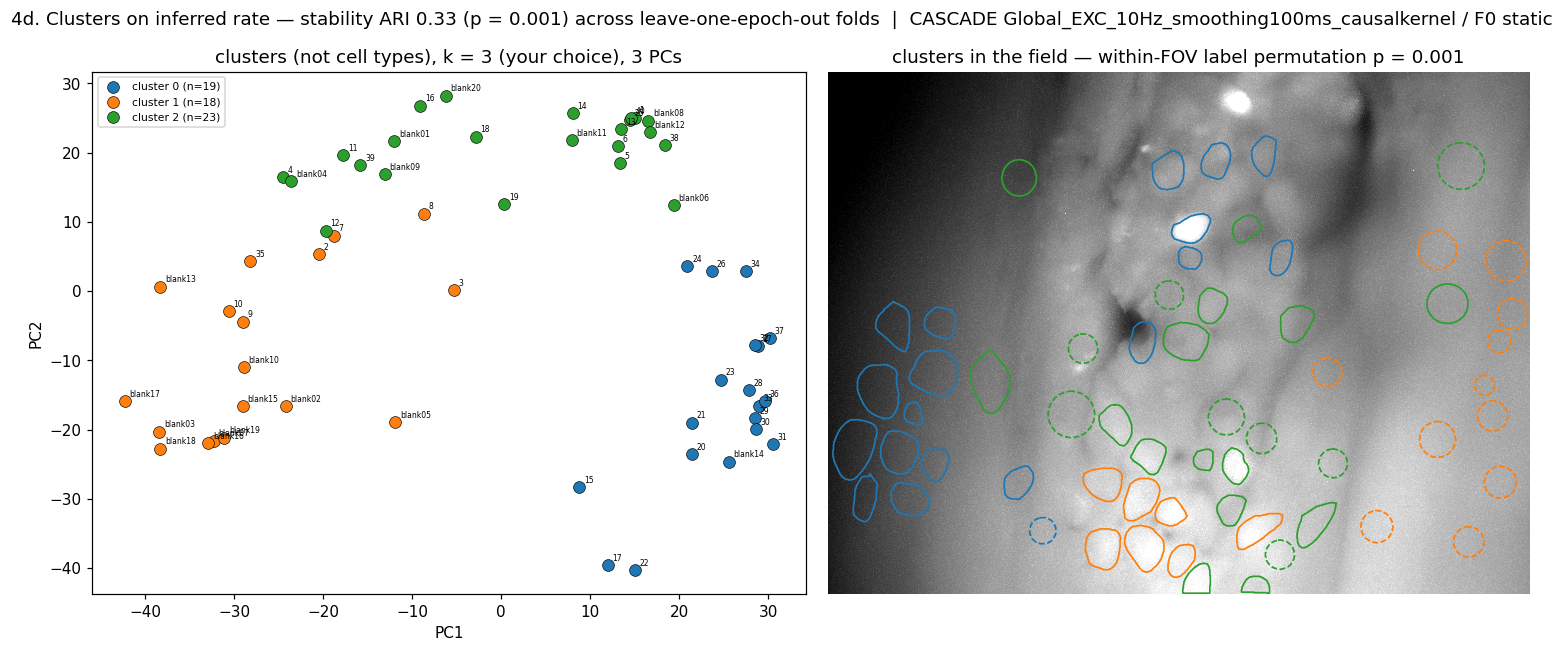

,signal,k,stability_ari,p_stability,mean_within_cluster_distance_px,p_spatial,sizes
0,dff,3,0.389,0.001,477.2,0.2108,"[38, 16, 6]"
1,cascade,3,0.328,0.001,419.9,0.0010,"[19, 18, 23]"


clusters fitted on both signals with k = 3 (user choice; CONFIG default 3) and 3 PCs  |  stability ARI dff 0.389, cascade 0.328  |  N cells 40 real + 20 blank


In [26]:
def mean_within_cluster_distance(labels: np.ndarray, dist: np.ndarray, sel: np.ndarray) -> float:
    """Mean centroid distance between same-cluster ROI pairs, real ROIs only."""
    i, j = np.triu_indices(sel.sum(), 1)
    same = labels[sel][i] == labels[sel][j]
    return float(dist[np.ix_(sel, sel)][i, j][same].mean()) if same.any() else np.nan


K_CHOSEN = int(k_input.value)
if K_CHOSEN < 2 or K_CHOSEN >= n_roi:
    raise ValueError(f"k must be an integer in 2..{n_roi - 1}; the box holds {k_input.value!r}.")

roi_dist_px = np.linalg.norm(roi_centroids[:, None, :] - roi_centroids[None, :, :], axis=-1)
cluster_summary, cluster_labels = [], {}
for signal, X_all in (("dff", dff[F0_PRIMARY].T), ("cascade", rates[PRIMARY_KEY])):
    finite = np.isfinite(X_all).all(axis=0)
    full_labels, emb = cluster_once(X_all[:, finite], K_CHOSEN)
    stability, fold_labels = fold_stability(X_all, finite, K_CHOSEN)
    rng = np.random.default_rng(CLUSTER_SEED)
    null = [adjusted_rand_score(rng.permutation(full_labels), rng.permutation(full_labels))
            for _ in range(N_PERM_LABEL)]
    p_stab = (np.sum(np.asarray(null) >= stability) + 1) / (N_PERM_LABEL + 1)

    obs_d = mean_within_cluster_distance(full_labels, roi_dist_px, ~is_blank)
    null_d = np.array([mean_within_cluster_distance(rng.permutation(full_labels), roi_dist_px,
                                                    ~is_blank) for _ in range(N_PERM_LABEL)])
    p_space = (np.sum(null_d <= obs_d) + 1) / (N_PERM_LABEL + 1)   # within-FOV label permutation

    cluster_labels[signal] = full_labels
    cluster_summary.append({"signal": signal, "k": K_CHOSEN, "stability_ari": round(stability, 3),
                            "p_stability": round(float(p_stab), 4),
                            "mean_within_cluster_distance_px": round(obs_d, 1),
                            "p_spatial": round(float(p_space), 4),
                            "sizes": np.bincount(full_labels, minlength=K_CHOSEN).tolist()})
    if signal == "cascade":
        fig, (ax_e, ax_f) = plt.subplots(1, 2, figsize=(14, 6))
        for c in range(K_CHOSEN):
            sel = full_labels == c
            ax_e.scatter(emb[sel, 0], emb[sel, 1], s=60, color=plt.cm.tab10(c % 10),
                         edgecolor="k", linewidth=0.4, label=f"cluster {c} (n={int(sel.sum())})")
        for j in range(n_roi):
            ax_e.annotate(roi_labels[j], emb[j, :2], fontsize=5, xytext=(3, 3),
                          textcoords="offset points")
        ax_e.set_xlabel("PC1"); ax_e.set_ylabel("PC2"); ax_e.legend(fontsize=7)
        ax_e.set_title(f"clusters (not cell types), k = {K_CHOSEN} (your choice), "
                       f"{PCA_N_COMPONENTS} PCs")
        mp_lo, mp_hi = np.percentile(max_proj, [2, 99.5])
        ax_f.imshow(max_proj, cmap="gray", vmin=mp_lo, vmax=mp_hi)
        for j, mask in enumerate(roi_masks):
            ax_f.contour(mask, levels=[0.5], colors=[plt.cm.tab10(full_labels[j] % 10)],
                         linewidths=1.1, linestyles="dashed" if is_blank[j] else "solid")
        ax_f.set_title(f"clusters in the field — within-FOV label permutation p = {p_space:.3f}")
        ax_f.axis("off")
        fig.suptitle(f"4d. Clusters on inferred rate — stability ARI {stability:.2f} "
                     f"(p = {p_stab:.3f}) across leave-one-epoch-out folds  |  {SPIKE_TAG}")
        fig.tight_layout()
        save_fig(fig, "4d_clusters")
        plt.show()

cluster_table = pd.DataFrame(cluster_summary)
record("population", pca_components=PCA_N_COMPONENTS, k_chosen=K_CHOSEN, k_config_default=PCA_K,
       k_selection="user-entered in the §4d box after reading the landscape; no argmax taken",
       k_landscape=k_table.to_dict("records"), seed=CLUSTER_SEED,
       folds="leave-one-epoch-out; normalisation and PCA fitted inside each fold",
       n_perm_label=N_PERM_LABEL, clusters=cluster_table.to_dict("records"))
display(cluster_table)
print(f"clusters fitted on both signals with k = {K_CHOSEN} (user choice; CONFIG default "
      f"{PCA_K}) and {PCA_N_COMPONENTS} PCs  |  stability ARI "
      + ", ".join(f"{r['signal']} {r['stability_ari']}" for r in cluster_summary)
      + f"  |  N cells {n_real} real + {n_blank} blank")

### 4e. dF/F against inferred rate — do they agree?

Every primary endpoint exists twice (C4); this is where the two are compared rather than one being
picked. Mantel keeps the ROI-pair dependence intact by permuting ROI labels; the endpoint panel
compares per-cell epoch effects and responder identity. Divergence is interpreted — saturation,
smoothing, model mismatch, drift, SNR — not resolved by choosing the significant one (B Step 10).

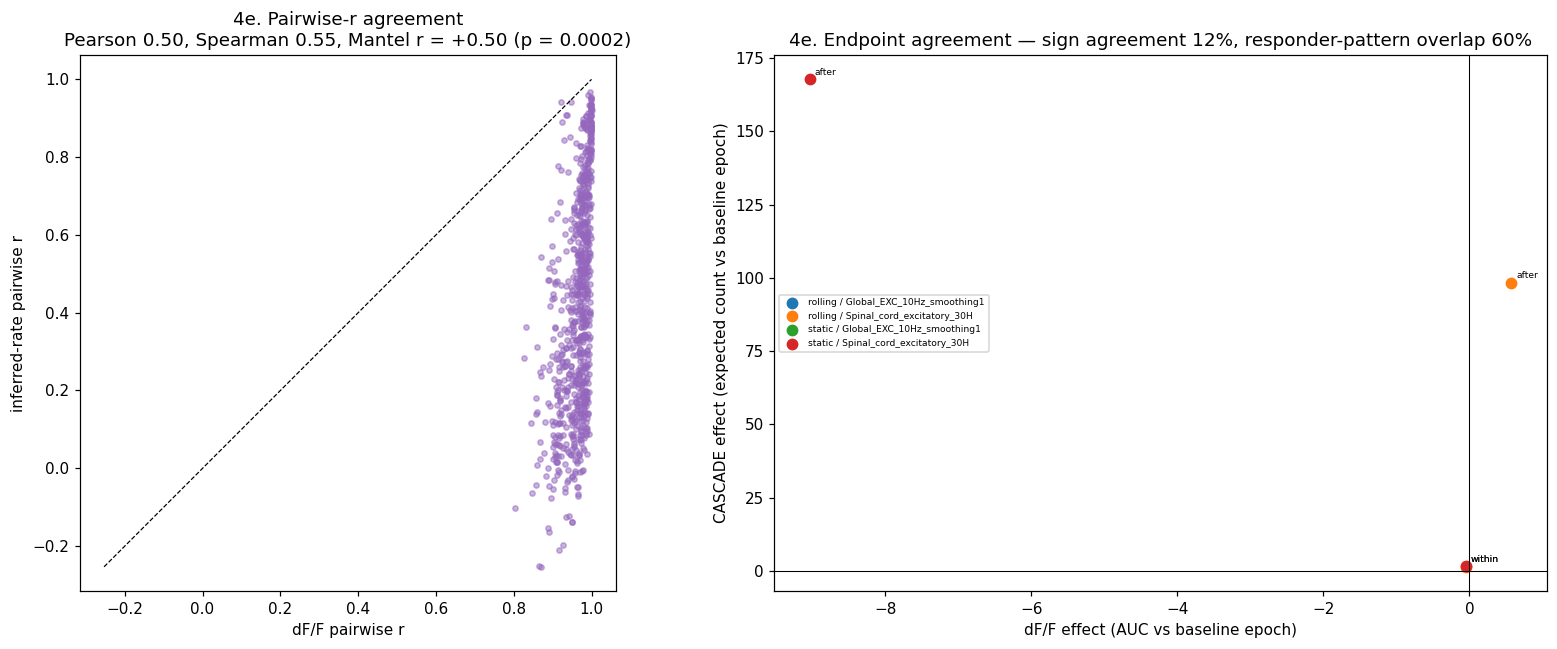

Mantel r = +0.503 (p = 0.0002, 5000 ROI-label permutations) over 780 real ROI pairs  |  endpoint sign agreement 12% over 8 contrasts  |  responder-pattern overlap 60%  |  N mice 1 / sessions 1 / FOVs 1 / cells 40 real + 20 blank / trials 1


In [27]:
def mantel_test(A: np.ndarray, B: np.ndarray, n_perm: int = 5000, seed: int = 0):
    """Correlation between two similarity matrices, with an ROI-label permutation p-value."""
    rng = np.random.default_rng(seed)
    a = offdiag(A)
    a = (a - a.mean()) / np.linalg.norm(a - a.mean())

    def score(M):
        b = offdiag(M)
        b = b - b.mean()
        return float(a @ (b / np.linalg.norm(b)))

    observed = score(B)
    ge = 1                                    # count the observed statistic itself
    for _ in range(n_perm):
        order = rng.permutation(A.shape[0])
        ge += score(B[np.ix_(order, order)]) >= observed
    return observed, ge / (n_perm + 1)


real_corr = {k: v[:n_real, :n_real] for k, v in corr.items()}
mantel_r, mantel_p = mantel_test(real_corr["dff"], real_corr["cascade"], seed=CLUSTER_SEED)
r_dff, r_rate = offdiag(real_corr["dff"]), offdiag(real_corr["cascade"])

eff = (contrasts[(contrasts["roi_set"] == "real") & (contrasts["feature"] == "integral")]
       .pivot(index=["epoch", "baseline", "model"], columns="signal", values="effect"))
sign_agree = float((np.sign(eff["dff"]) == np.sign(eff["cascade"])).mean())
pat = primary_pheno.pivot(index="roi", columns="signal", values="pattern")
overlap = float((pat["dff"] == pat["cascade"]).mean())

fig, (ax_s, ax_e) = plt.subplots(1, 2, figsize=(15, 6))
lo, hi = min(r_dff.min(), r_rate.min()), max(r_dff.max(), r_rate.max())
ax_s.plot([lo, hi], [lo, hi], "k--", lw=0.8)
ax_s.scatter(r_dff, r_rate, s=12, alpha=0.5, color="tab:purple")
ax_s.set_xlabel("dF/F pairwise r"); ax_s.set_ylabel("inferred-rate pairwise r")
ax_s.set_aspect("equal")
ax_s.set_title(f"4e. Pairwise-r agreement\nPearson {pearsonr(r_dff, r_rate)[0]:.2f}, "
               f"Spearman {spearmanr(r_dff, r_rate)[0]:.2f}, Mantel r = {mantel_r:+.2f} "
               f"(p = {mantel_p:.4f})")
for (baseline, model), part in eff.groupby(level=["baseline", "model"]):
    ax_e.scatter(part["dff"], part["cascade"], s=45, label=f"{baseline} / {model[:26]}")
for (epoch, baseline, model), row in eff.iterrows():
    ax_e.annotate(epoch, (row["dff"], row["cascade"]), fontsize=6, xytext=(3, 3),
                  textcoords="offset points")
ax_e.axhline(0, color="k", lw=0.7); ax_e.axvline(0, color="k", lw=0.7)
ax_e.set_xlabel("dF/F effect (AUC vs baseline epoch)")
ax_e.set_ylabel("CASCADE effect (expected count vs baseline epoch)")
ax_e.set_title(f"4e. Endpoint agreement — sign agreement {100 * sign_agree:.0f}%, "
               f"responder-pattern overlap {100 * overlap:.0f}%")
ax_e.legend(fontsize=6)
fig.tight_layout()
save_fig(fig, "4e_agreement")
plt.show()

record("agreement", mantel_r=float(mantel_r), mantel_p=float(mantel_p), mantel_n_perm=5000,
       pairwise_pearson=float(pearsonr(r_dff, r_rate)[0]),
       pairwise_spearman=float(spearmanr(r_dff, r_rate)[0]),
       endpoint_sign_agreement=sign_agree, responder_pattern_overlap=overlap)
print(f"Mantel r = {mantel_r:+.3f} (p = {mantel_p:.4f}, 5000 ROI-label permutations) over "
      f"{len(r_dff)} real ROI pairs  |  endpoint sign agreement {100 * sign_agree:.0f}% over "
      f"{len(eff)} contrasts  |  responder-pattern overlap {100 * overlap:.0f}%  |  N mice 1 / "
      f"sessions 1 / FOVs 1 / cells {n_real} real + {n_blank} blank / trials 1")

### 4f. Dataset-specific model — see A §3–§5 / B §5–§7

Stub. This notebook builds the **shared backbone** only. The Data_L circular-tuning model, the
Data_M frequency/adaptation model and the Data_D difference-in-differences model sit on top of
`features.csv` and are out of scope here (B §4).

### Run manifest

The reproducibility record for this run: provenance, F₀ frames and drift method, timestamps, ROI
and motion settings, CASCADE model files and flags, epoch definitions, feature formulas and units,
surrogate seed and hierarchy, multiplicity family, and every level of N (B §9).

In [28]:
record("counts", n_mice=1, n_sessions=1, n_fovs=1, n_cells_real=n_real, n_cells_blank=n_blank,
       n_trials=1, n_frames=n_frames, n_frames_censored=int(motion_censored.sum()))
record("software", numpy=np.__version__, pandas=pd.__version__,
       notebook_sections="0 setup / 1 load / 2 preprocess / 3 inference / 4 analysis / A appendix")
manifest_path = write_manifest()
print(f"run manifest -> {manifest_path}  ({len(json.loads(manifest_path.read_text()))} sections)  |  "
      f"tables -> {OUTPUT_DIR}/features.csv, responses.csv, phenotypes.csv, contrasts.csv, "
      f"drift_audit.csv, motion_per_frame.csv")

run manifest -> analysis_cache/run_manifest.json  (14 sections)  |  tables -> main_output/features.csv, responses.csv, phenotypes.csv, contrasts.csv, drift_audit.csv, motion_per_frame.csv


## A. Appendix

Everything that does not feed the load → preprocess → infer → analyse path: QC comparisons, the
field movie, napari, exploratory landscapes, and the robustness panel. **Nothing here writes back
into §0–§4.** The two exploratory sweeps below were §9b and §10c of the previous notebook; they
are demoted because both select an analysis parameter on the same data used to report the result.

### A1. Denoise comparison — NLM against Gaussian

Non-local means keeps somatic boundaries that a Gaussian of comparable strength smears, at
~0.5 s/frame against a few ms. Set `DENOISE_METHOD` in Config from what you see here.

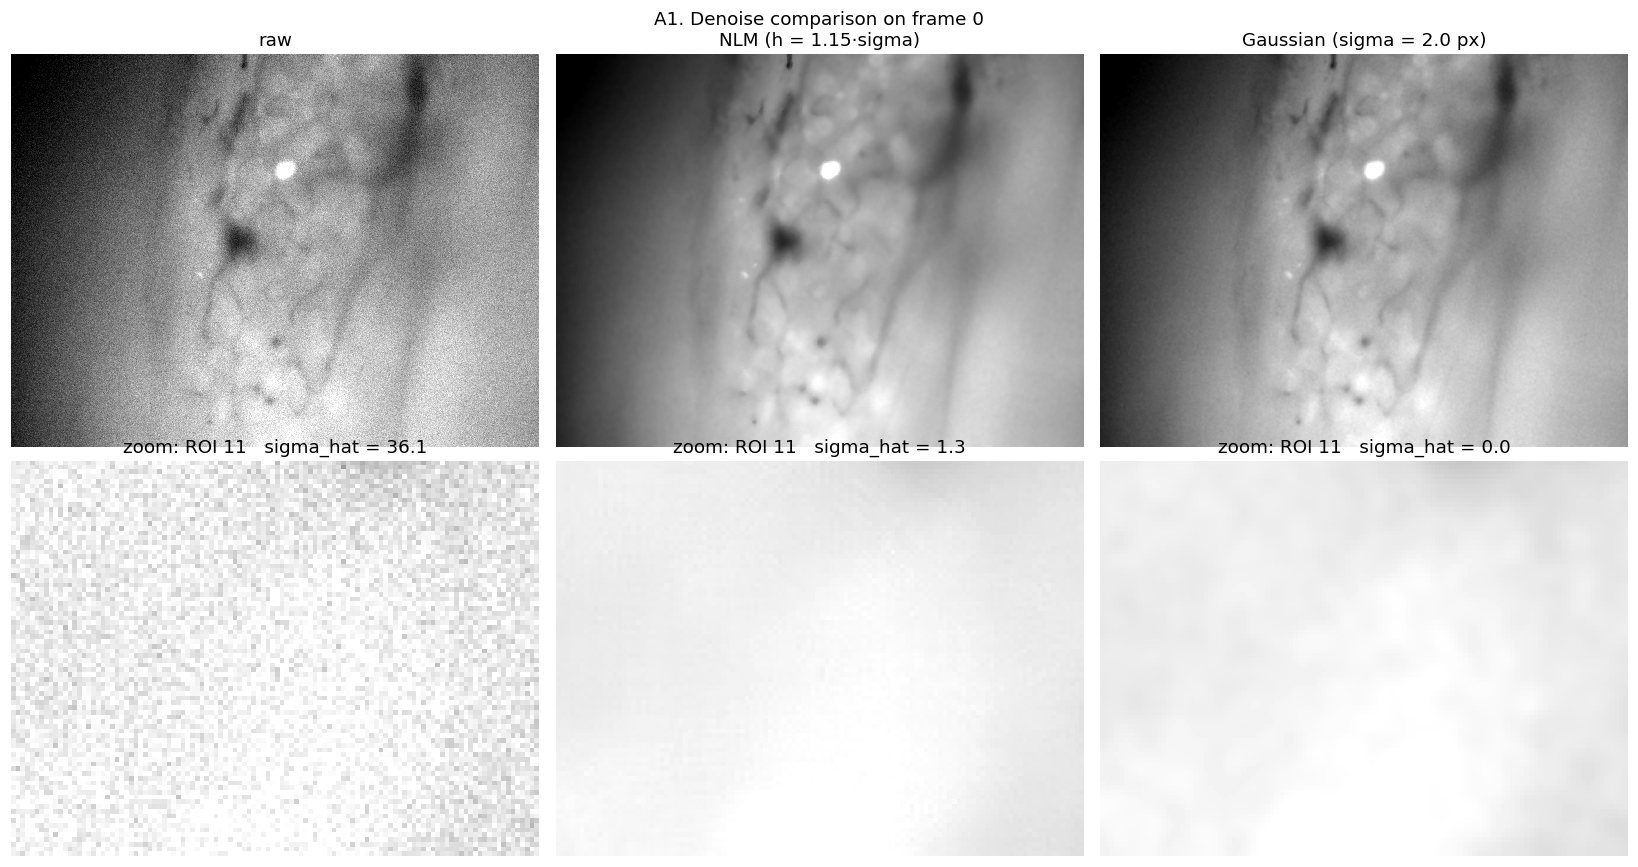

sigma_hat frame 0: raw 36.10 | NLM 1.25 | Gaussian 0.04  (in use: nlm)


In [29]:
raw0 = load_frame(0).astype(np.float32)
panels = [("raw", raw0),
          (f"NLM (h = {NLM_H_FACTOR}·sigma)", denoise(raw0, "nlm")),
          (f"Gaussian (sigma = {GAUSSIAN_SIGMA} px)", denoise(raw0, "gaussian"))]

brightest = int(np.argmax([raw0[m].mean() for m in roi_masks]))
cy, cx = roi_centroids[brightest].astype(int)
pad = int(2 * np.sqrt(roi_area_px[brightest] / np.pi))
sl = (slice(max(cy - pad, 0), cy + pad), slice(max(cx - pad, 0), cx + pad))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
vmin, vmax = np.percentile(raw0, [1, 99.5])
for col, (title, img) in enumerate(panels):
    axes[0, col].imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    axes[0, col].set_title(title)
    axes[1, col].imshow(img[sl], cmap="gray", vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f"zoom: ROI {roi_labels[brightest]}   sigma_hat = {noise_sigma(img):.1f}")
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("A1. Denoise comparison on frame 0")
fig.tight_layout()
save_fig(fig, "A1_denoise_comparison")
plt.show()
print(f"sigma_hat frame 0: raw {noise_sigma(raw0):.2f} | NLM {noise_sigma(panels[1][1]):.2f} | "
      f"Gaussian {noise_sigma(panels[2][1]):.2f}  (in use: {DENOISE_METHOD})")

### A2. Inferred-rate population heatmap

Population QC across models and baselines, clipped at the 99.5th percentile because the largest
single bin would otherwise push everything else to near-black. Continuous inferred rate, never
thresholded events (C1).

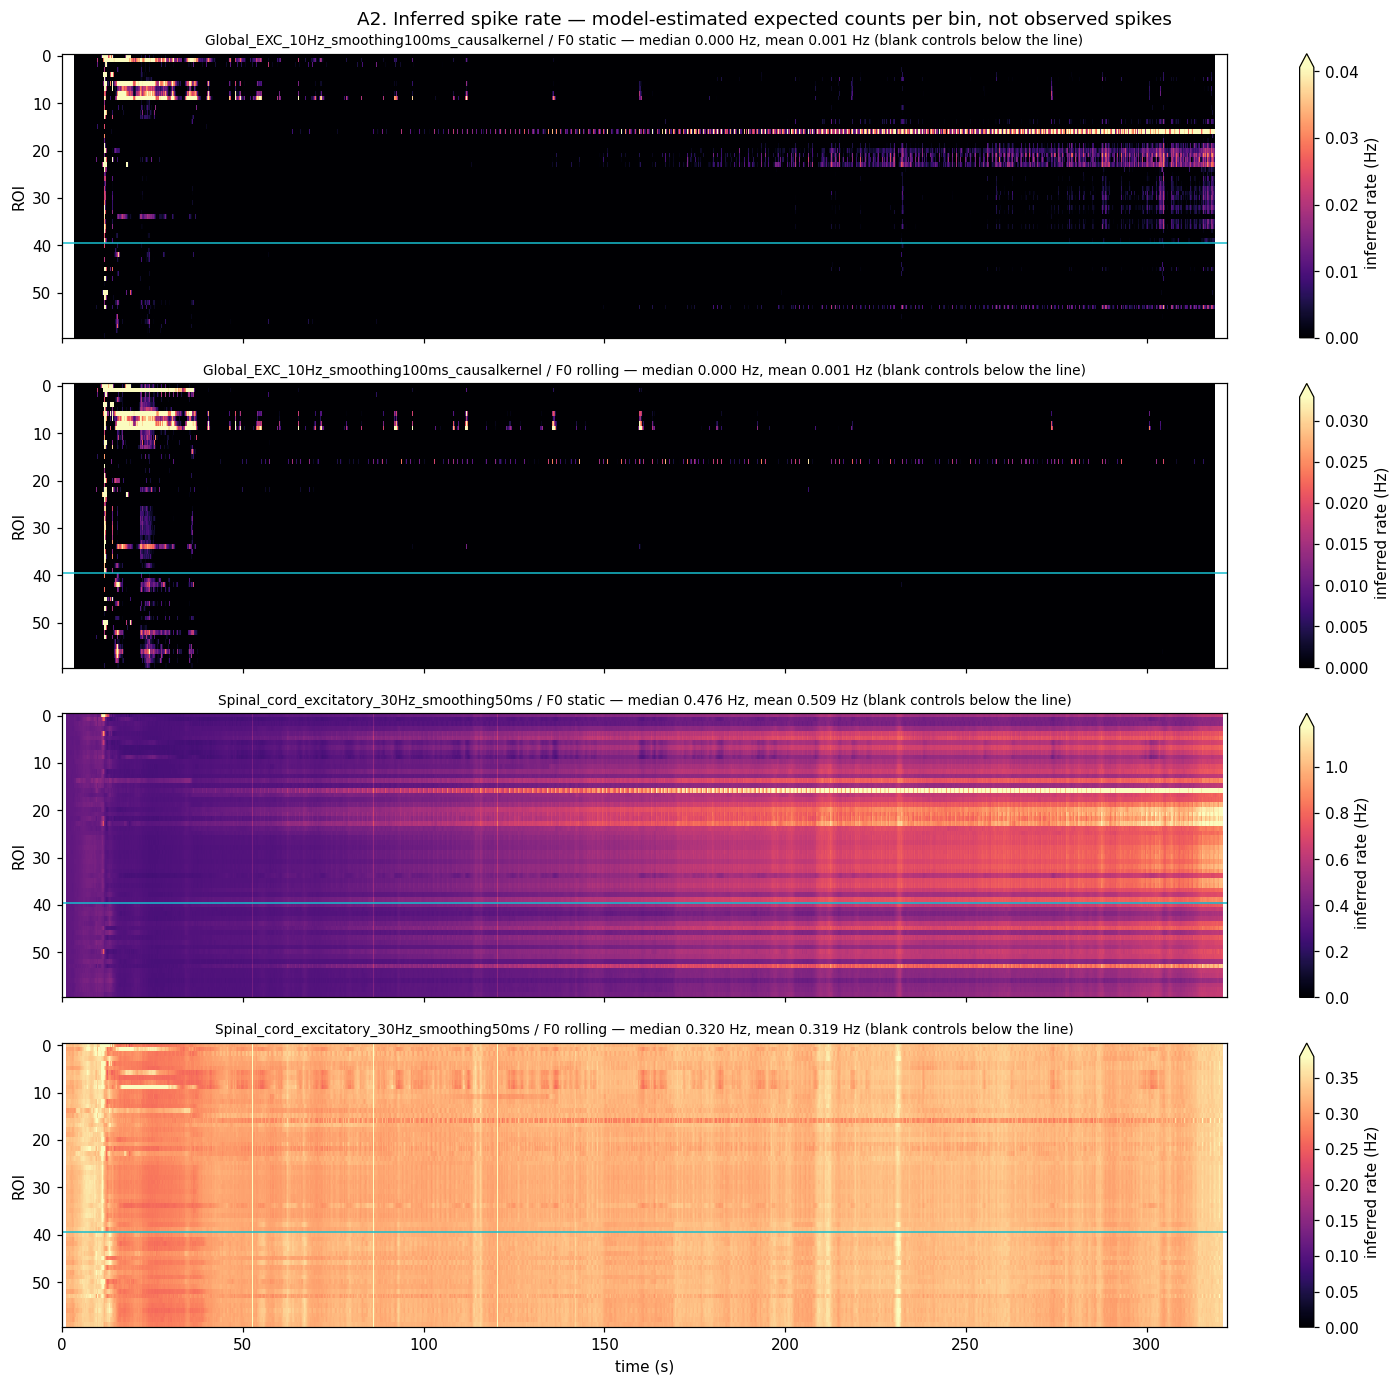

Global_EXC_10Hz_smooth/static: mean real 0.001 Hz vs blank 0.000 Hz  |  Global_EXC_10Hz_smooth/rolling: mean real 0.001 Hz vs blank 0.000 Hz  |  Spinal_cord_excitatory/static: mean real 0.537 Hz vs blank 0.454 Hz  |  Spinal_cord_excitatory/rolling: mean real 0.319 Hz vs blank 0.321 Hz


In [30]:
HEAT_CLIP_PCT = 99.5
fig, axes = plt.subplots(len(rates), 1, figsize=(14, 3.2 * len(rates)), sharex=True, squeeze=False)
for ax, ((model, baseline), R) in zip(axes[:, 0], rates.items()):
    finite = R[np.isfinite(R)]
    vmax = float(np.percentile(finite, HEAT_CLIP_PCT)) or float(finite.max() or 1.0)
    im = ax.imshow(np.ma.masked_invalid(R), aspect="auto", cmap="magma", vmin=0, vmax=vmax,
                   extent=[times_s[0], times_s[-1], n_roi - 0.5, -0.5])
    fig.colorbar(im, ax=ax, extend="max", label="inferred rate (Hz)")
    ax.axhline(n_real - 0.5, color="tab:cyan", lw=1.0)
    ax.set_ylabel("ROI")
    ax.set_title(f"{model} / F0 {baseline} — median {np.nanmedian(R):.3f} Hz, "
                 f"mean {np.nanmean(R):.3f} Hz (blank controls below the line)", fontsize=9)
axes[-1, 0].set_xlabel("time (s)")
fig.suptitle("A2. Inferred spike rate — model-estimated expected counts per bin, not observed spikes")
fig.tight_layout()
save_fig(fig, "A2_rate_heatmaps")
plt.show()
print("  |  ".join(f"{m[:22]}/{b}: mean real {np.nanmean(R[~is_blank]):.3f} Hz vs blank "
                   f"{np.nanmean(R[is_blank]):.3f} Hz" for (m, b), R in rates.items()))

### A3. Whole-field animation

Rendered at the frames' native resolution (`figsize = shape / 100` at `dpi = 100`): the source is
1024×1376, so a higher dpi upsamples the image and only sharpens the vector overlay while
multiplying the file size. Quality-targeted CRF encoding. Needs `ffmpeg` on PATH.

In [31]:
MOVIE_PATH = (OUTPUT_DIR if SAVE_OUTPUTS else CACHE_DIR) / f"field_ch{CHANNEL}_step{MOVIE_STEP}.mp4"


def render_movie(path: Path = MOVIE_PATH, step: int = MOVIE_STEP, overwrite: bool = False) -> Path:
    """Write the whole field to MP4 with static ROI outlines overlaid."""
    if path.exists() and path.stat().st_size > 0 and not overwrite:
        print(f"using cached movie: {path} ({path.stat().st_size / 1024**2:.1f} MB)")
        return path
    if not animation.writers.is_available("ffmpeg"):
        raise RuntimeError("ffmpeg is required (macOS: brew install ffmpeg).")
    path.parent.mkdir(parents=True, exist_ok=True)

    rows = np.arange(0, n_frames, step)
    sample = np.linspace(0, n_frames - 1, min(12, n_frames)).astype(int)
    lo, hi = np.percentile(np.concatenate([load_frame(int(r))[::8, ::8].ravel() for r in sample]),
                           [1, 99])

    height, width = frame_shape
    fig, ax = plt.subplots(figsize=(width / 100, height / 100))
    art = ax.imshow(load_frame(int(rows[0])), cmap="gray", vmin=lo, vmax=max(hi, lo + 1))
    for j, mask in enumerate(roi_masks):          # static: drawn once, not per frame
        ax.contour(mask, levels=[0.5], colors=["tab:cyan" if is_blank[j] else "tab:orange"],
                   linewidths=0.7)
        ax.text(roi_centroids[j, 1], roi_centroids[j, 0], roi_labels[j],
                color="yellow", fontsize=6, ha="center", va="center", weight="bold")
    title = ax.set_title("")
    ax.axis("off")
    fig.subplots_adjust(left=0, right=1, bottom=0, top=0.95)

    writer = animation.FFMpegWriter(
        fps=MOVIE_FPS, codec="libx264", bitrate=-1,
        extra_args=["-crf", "20", "-preset", "medium", "-pix_fmt", "yuv420p",
                    "-movflags", "+faststart"])
    with writer.saving(fig, str(path), dpi=100):
        for r in tqdm(rows, desc="writing MP4"):
            art.set_data(load_frame(int(r)))
            title.set_text(f"Ch{CHANNEL}  frame {int(r)}  t = {times_s[int(r)]:.1f}s  "
                           f"({n_real} ROIs + {n_blank} blanks)")
            writer.grab_frame()
    plt.close(fig)
    print(f"{len(rows)} frames -> {path} ({path.stat().st_size / 1024**2:.1f} MB)")
    return path


display(Video(str(render_movie()), embed=False, html_attributes="controls preload='metadata'"))

using cached movie: analysis_cache/field_ch0_step1.mp4 (759.5 MB)


### A4. Napari viewer — optional, off by default

Set `USE_NAPARI = True` in Config to open the stack lazily (dask-backed) with the ROI label layer
editable. Repaint masks, uncomment the write-back line to persist them, then re-run from §1.

In [32]:
if USE_NAPARI:
    import dask
    import dask.array as da
    import napari

    lazy_stack = da.stack([
        da.from_delayed(dask.delayed(load_frame)(i), shape=frame_shape, dtype=np.uint16)
        for i in range(n_frames)
    ], axis=0)

    viewer = napari.Viewer()
    viewer.add_image(lazy_stack, name="raw stack")
    viewer.add_image(max_proj, name="max projection", visible=False)
    roi_layer = viewer.add_labels(label_map.astype(np.uint16), name="ROI mask", opacity=0.6)

    # Persist edits, then re-run from §1 so every downstream cache key changes:
    #   tifffile.imwrite(ROI_LABEL_PATH, roi_layer.data.astype(np.uint16))
    print("napari open — paint on the 'ROI mask' layer, then save with the line above.")
else:
    print("napari disabled (USE_NAPARI = False). Set it True in Config to enable.")

napari disabled (USE_NAPARI = False). Set it True in Config to enable.


### A5. Exploratory — parameter landscape, not a selection rule

The 2-D version of the §4d k curve: silhouette and trace coherence across
(`PCA_COMP_GRID` × `PCA_K_GRID`), i.e. also varying how many components k-means sees. Taking the
argmax here and reporting the clustering from the same data is post-selection inference (A §1.5,
B §2.1 Chen et al.) — §4d instead uses the k *you* entered. A broad plateau means the choice
barely matters; a sharp isolated peak means the opposite.

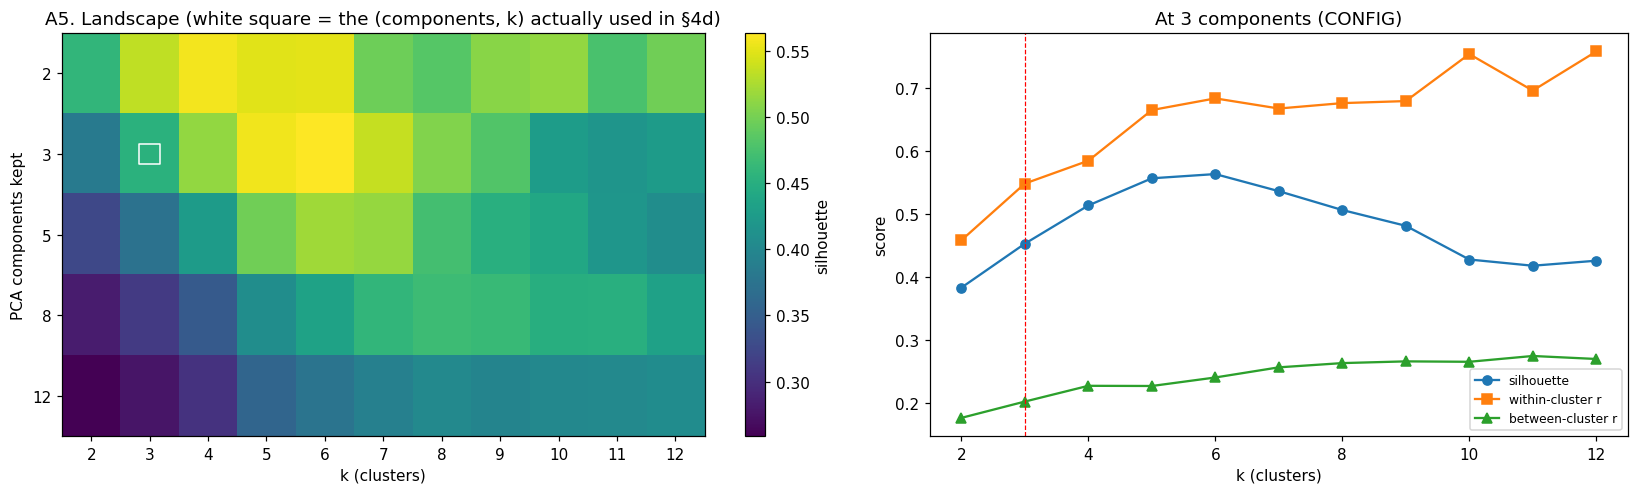

,n_components,k,silhouette,within_r,between_r,separation,smallest_cluster
0,2,2,0.460,0.462,0.171,0.291,28
1,2,3,0.535,0.538,0.208,0.330,19
2,2,4,0.558,0.585,0.230,0.356,13
3,2,5,0.549,0.594,0.237,0.357,3
4,2,6,0.551,0.566,0.258,0.308,3
5,2,7,0.497,0.624,0.258,0.366,3
6,2,8,0.483,0.648,0.265,0.383,3
7,2,9,0.509,0.659,0.267,0.392,3
8,2,10,0.514,0.725,0.261,0.464,3
9,2,11,0.476,0.693,0.275,0.418,2


landscape over 55 (components, k) pairs — NOT used to choose anything; §4d used (3 components, k = 3)


In [33]:
def cluster_coherence(corr_m: np.ndarray, labels: np.ndarray) -> tuple[float, float]:
    """Mean pairwise r within clusters vs across clusters — 'are these traces alike?'."""
    i, j = np.triu_indices(len(labels), 1)
    same = labels[i] == labels[j]
    r = corr_m[i, j]
    return (float(r[same].mean()) if same.any() else np.nan,
            float(r[~same].mean()) if (~same).any() else np.nan)


def cluster_grid(X: np.ndarray, corr_m: np.ndarray, seed: int = CLUSTER_SEED) -> pd.DataFrame:
    """Silhouette and trace coherence for every (n components, k) on the exploratory grid."""
    sd = X.std(axis=1, keepdims=True)
    Z = (X - X.mean(axis=1, keepdims=True)) / np.where(sd > 0, sd, 1.0)
    rows = []
    for n_comp in PCA_COMP_GRID:
        if n_comp > min(Z.shape):
            continue
        emb = PCA(n_components=n_comp, random_state=seed).fit_transform(Z)
        for k in PCA_K_GRID:
            if k >= Z.shape[0]:
                continue
            labels = KMeans(n_clusters=k, n_init=20, random_state=seed).fit_predict(emb)
            within, between = cluster_coherence(corr_m, labels)
            rows.append({"n_components": n_comp, "k": k,
                         "silhouette": float(silhouette_score(emb, labels)),
                         "within_r": within, "between_r": between,
                         "separation": within - between,
                         "smallest_cluster": int(np.bincount(labels).min())})
    return pd.DataFrame(rows)


X_expl = rates[PRIMARY_KEY][:, np.isfinite(rates[PRIMARY_KEY]).all(axis=0)]
grid = cluster_grid(X_expl, corr["cascade"])
pivot = grid.pivot(index="n_components", columns="k", values="silhouette")

fig, (ax_g, ax_k) = plt.subplots(1, 2, figsize=(15, 4.6), width_ratios=[1.15, 1])
im = ax_g.imshow(pivot.to_numpy(), cmap="viridis", aspect="auto")
fig.colorbar(im, ax=ax_g, label="silhouette")
ax_g.set_xticks(range(len(pivot.columns))); ax_g.set_xticklabels(pivot.columns)
ax_g.set_yticks(range(len(pivot.index))); ax_g.set_yticklabels(pivot.index)
ax_g.set_xlabel("k (clusters)"); ax_g.set_ylabel("PCA components kept")
if K_CHOSEN in list(pivot.columns) and PCA_N_COMPONENTS in list(pivot.index):
    ax_g.scatter(list(pivot.columns).index(K_CHOSEN), list(pivot.index).index(PCA_N_COMPONENTS),
                 marker="s", s=180, facecolor="none", edgecolor="white", zorder=3)
ax_g.set_title("A5. Landscape (white square = the (components, k) actually used in §4d)")
at_config = grid[grid["n_components"] == PCA_N_COMPONENTS]
ax_k.plot(at_config["k"], at_config["silhouette"], "o-", label="silhouette")
ax_k.plot(at_config["k"], at_config["within_r"], "s-", label="within-cluster r")
ax_k.plot(at_config["k"], at_config["between_r"], "^-", label="between-cluster r")
ax_k.axvline(K_CHOSEN, ls="--", lw=0.8, color="red")
ax_k.set_xlabel("k (clusters)"); ax_k.set_ylabel("score")
ax_k.set_title(f"At {PCA_N_COMPONENTS} components (CONFIG)")
ax_k.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "A5_cluster_landscape")
plt.show()
display(grid.round(3))
print(f"landscape over {len(grid)} (components, k) pairs — NOT used to choose anything; §4d used "
      f"({PCA_N_COMPONENTS} components, k = {K_CHOSEN})")

### A6. Exploratory — interactive split preview

Drag to look at arbitrary splits of the recording. This is a viewer only: the epochs used anywhere
in §4 come from `EPOCH_BOUNDS_S` and nothing here can change them (C5, B Step 1).

In [34]:
population_dff = dff[F0_PRIMARY][:, ~is_blank].mean(axis=1)
predicted = np.isfinite(rates[PRIMARY_KEY]).any(axis=0)
population_rate = np.full(n_frames, np.nan)
population_rate[predicted] = np.nanmean(rates[PRIMARY_KEY][~is_blank][:, predicted], axis=0)


def preview_split(bounds):
    """Population activity with candidate boundaries shaded, against the declared epochs."""
    fig, (ax_a, ax_r) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    ax_a.plot(times_s, population_dff, lw=0.6, color="k")
    ax_a.set_ylabel("population mean dF/F")
    ax_r.plot(times_s, population_rate, lw=0.6, color="tab:red")
    ax_r.set_ylabel(f"population mean\ninferred rate (Hz)")
    ax_r.set_xlabel("time (s)")
    for ax in (ax_a, ax_r):
        for b in np.atleast_1d(bounds):
            ax.axvline(float(b), color="tab:blue", lw=1.4)
        for b in EPOCH_BOUNDS_S:
            ax.axvline(float(b), color="k", ls=":", lw=1.0)
    ax_a.set_title(f"A6. Candidate split (blue) at {tuple(round(float(b), 1) for b in np.atleast_1d(bounds))} s "
                   f"— declared epochs (dotted black) are unaffected")
    fig.tight_layout()
    plt.show()


widgets.interact(preview_split, bounds=widgets.FloatRangeSlider(
    value=(float(STIM_ONSET_S), float(STIM_OFFSET_S)), min=float(times_s[0]), max=float(times_s[-1]),
    step=round(float(times_s[-1]) / 200, 2), description="candidate", continuous_update=False,
    readout_format=".1f", layout=widgets.Layout(width="92%")))
print("viewer only — §4 epochs come from EPOCH_BOUNDS_S and are unaffected by this slider")

interactive(children=(FloatRangeSlider(value=(3.0, 10.0), continuous_update=False, description='candidate', la…

viewer only — §4 epochs come from EPOCH_BOUNDS_S and are unaffected by this slider


### A7. Exploratory — where does structure change? (not used to define epochs)

Scores every candidate split by the mean RMS difference between the per-phase ROI correlation
matrices. The score is maximised over the same data it is computed on, so a peak locates a
*candidate* boundary and establishes nothing. Primary epochs come from `EPOCH_BOUNDS_S` only.

In [35]:
def phase_slices(t: np.ndarray, bounds_s) -> list[np.ndarray]:
    """Boolean masks over `t` for consecutive phases split at the interior boundaries."""
    edges = [t[0] - 1e-9, *sorted(float(b) for b in bounds_s), t[-1] + 1e-9]
    return [(t > edges[i]) & (t <= edges[i + 1]) for i in range(len(edges) - 1)]


def split_score(bounds, src: np.ndarray, t: np.ndarray) -> float:
    """Mean RMS difference between the ROI correlation matrices of each phase."""
    masks = phase_slices(t, bounds)
    if any(m.sum() < SWEEP_MIN_S * fps for m in masks):
        return np.nan
    mats = [np.corrcoef(src[:, m]) for m in masks]
    if any(not np.isfinite(m).all() for m in mats):
        return np.nan
    return float(np.mean([np.sqrt(((offdiag(a) - offdiag(b)) ** 2).mean())
                          for a, b in itertools.combinations(mats, 2)]))


def scan_splits(n_phases: int, src: np.ndarray, t: np.ndarray, n_grid: int = 40) -> pd.DataFrame:
    candidates = np.linspace(t[0] + SWEEP_MIN_S, t[-1] - SWEEP_MIN_S, n_grid)
    rows = [{"n_phases": n_phases, "bounds": tuple(round(float(b), 1) for b in bounds),
             "score": split_score(bounds, src, t)}
            for bounds in itertools.combinations(candidates, n_phases - 1)]
    return pd.DataFrame([r for r in rows if np.isfinite(r["score"])])


source = rates[PRIMARY_KEY][~is_blank]
keep_t = np.isfinite(source).all(axis=0)
src, t_src = source[:, keep_t], times_s[keep_t]
scans = pd.concat([scan_splits(n, src, t_src) for n in SWEEP_N_GRID], ignore_index=True)
best_per_n = scans.loc[scans.groupby("n_phases")["score"].idxmax()].reset_index(drop=True)
peak_of = dict(zip(best_per_n["n_phases"], best_per_n["bounds"]))

fig, (ax_1d, ax_2d, ax_n) = plt.subplots(1, 3, figsize=(17, 4.6))
two = scans[scans["n_phases"] == 2]
if not two.empty:
    ax_1d.plot([b[0] for b in two["bounds"]], two["score"], color="tab:blue")
    ax_1d.axvline(peak_of[2][0], ls="--", color="red", lw=0.9)
    ax_1d.set_title(f"2 phases: peak at {peak_of[2][0]} s")
for b in EPOCH_BOUNDS_S:
    ax_1d.axvline(float(b), ls=":", color="k", lw=0.9)
ax_1d.set_xlabel("boundary (s)"); ax_1d.set_ylabel("structure change (RMS dr)")
three = scans[scans["n_phases"] == 3]
if not three.empty:
    sc = ax_2d.scatter([b[0] for b in three["bounds"]], [b[1] for b in three["bounds"]],
                       c=three["score"], cmap="viridis", s=18)
    fig.colorbar(sc, ax=ax_2d, label="structure change")
    ax_2d.scatter(*peak_of[3], marker="*", s=280, color="red", edgecolor="white", zorder=3)
    ax_2d.set_title(f"3 phases: peak at {peak_of[3]} s")
ax_2d.set_xlabel("boundary 1 (s)"); ax_2d.set_ylabel("boundary 2 (s)")
ax_n.bar(best_per_n["n_phases"].astype(str), best_per_n["score"], color="tab:purple")
ax_n.set_xlabel("number of phases"); ax_n.set_ylabel("best structure change")
ax_n.set_title("How many phases?")
fig.suptitle("A7. Exploratory — where does structure change? (not used to define epochs)")
fig.tight_layout()
save_fig(fig, "A7_split_sweep")
plt.show()
display(best_per_n.round(3))
print(f"{len(scans)} candidate splits scored, exploratory only — the §4 epochs remain "
      f"{tuple(float(b) for b in EPOCH_BOUNDS_S)} s from CONFIG")

/Users/samsonho/exit()/envs/Cajal/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/samsonho/exit()/envs/Cajal/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


KeyError: 'n_phases'

### A8. Robustness panel

The §4c headline contrast re-run along every axis both documents ask for (A §2 Step 6, B Step 12).
A conclusion either survives all axes or is reported as sensitive to the named axis. Axes that
this recording cannot support (a single stimulus presentation, one causal setting) say so rather
than printing a number.

In [ ]:
def headline_effect(feat: pd.DataFrame, signal: str, baseline: str, model: str,
                    roi_set: str = "real", epoch: str | None = None) -> dict:
    """The §4c estimator on any feature table: mean per-cell (epoch - baseline epoch) + 95% CI."""
    delta = cell_deltas(feat, HEADLINE["feature"], HEADLINE["epoch"] if epoch is None else epoch,
                        signal, baseline, model, roi_set == "blank")
    est, lo, hi = hierarchical_bootstrap(delta, seed=CLUSTER_SEED)
    return {"effect": est, "ci_lo": lo, "ci_hi": hi, "n_cells": int(np.isfinite(delta).sum())}


rob = []


def add(axis: str, level: str, result: dict | None, note: str = "") -> None:
    rob.append({"axis": axis, "level": level,
                **(result or {"effect": np.nan, "ci_lo": np.nan, "ci_hi": np.nan, "n_cells": 0}),
                "sign": ("+" if result and result["effect"] > 0 else
                         "-" if result and result["effect"] < 0 else "n/a"),
                "note": note})


for b in (F0_PRIMARY, F0_SENSITIVITY):
    add("baseline", b, headline_effect(features, "cascade", b, PRIMARY_KEY[0]),
        "primary" if b == F0_PRIMARY else "sensitivity (CR-1)")
for s in ("dff", "cascade"):
    add("signal", s, headline_effect(features, s, F0_PRIMARY, PRIMARY_KEY[0]), "C4: both reported")
for m in CASCADE_MODELS:
    add("model", m[:34], headline_effect(features, "cascade", F0_PRIMARY, m),
        "frame-rate matched" if abs(model_specs[m]["rate_hz"] - fps) < 0.2 * fps else "tissue matched")
causal_models = {model_specs[m]["causal"]: m for m in CASCADE_MODELS}
if len(causal_models) == 2:
    for flag, m in causal_models.items():
        add("timing model", "causal" if flag else "symmetric",
            headline_effect(features, "cascade", F0_PRIMARY, m), m[:34])
else:
    add("timing model", "not evaluated", None,
        "configure one causal and one symmetric model to fill this row (B Step 12)")

jitter = {name: ((times_s >= row["t_start_s"] + guard_s + WINDOW_JITTER_S) &
                 (times_s <= row["t_end_s"] - guard_s - WINDOW_JITTER_S))
          for name, row in epochs.set_index("epoch").iterrows()}
if all(m.sum() >= MIN_EPOCH_FRAMES for m in jitter.values()):
    add("windows", f"shrunk by {WINDOW_JITTER_S:g} s",
        headline_effect(build_features(masks=jitter), "cascade", F0_PRIMARY, PRIMARY_KEY[0]),
        "guard + jitter")
else:
    add("windows", "not evaluated", None, f"an epoch drops below {MIN_EPOCH_FRAMES} frames")
add("windows", "declared", headline_effect(features, "cascade", F0_PRIMARY, PRIMARY_KEY[0]), "§1c")

add("motion", "censored (default)", headline_effect(features, "cascade", F0_PRIMARY, PRIMARY_KEY[0]),
    f"> {MOTION_CENSOR_PX} px dropped")
add("motion", "uncensored", headline_effect(build_features(censor=False), "cascade", F0_PRIMARY,
                                            PRIMARY_KEY[0]), "all frames kept")
add("trials", "not evaluable", None, "one stimulus presentation in this recording (n_trials = 1)")
for scale in (0.5, 1.0, 1.5):
    flags = (responses["effect_z"].abs() >= scale * responses["min_effect_z"]) & \
            (responses["excited"] | responses["inhibited"])
    frac = float(flags[~responses["is_blank"]].mean())
    fpr = float(flags[responses["is_blank"]].mean())
    rob.append({"axis": "responder threshold", "level": f"min effect x {scale:g}",
                "effect": frac, "ci_lo": np.nan, "ci_hi": np.nan,
                "n_cells": n_real, "sign": "+",
                "note": f"flagged fraction of real tests; blank FPR {fpr:.3f}"})
add("controls", "blank ROIs", headline_effect(features, "cascade", F0_PRIMARY, PRIMARY_KEY[0],
                                              roi_set="blank"), "same pipeline end to end")

robustness = pd.DataFrame(rob).round(4)
robustness.to_csv(OUTPUT_DIR / "robustness.csv", index=False)
record("robustness", file=str(OUTPUT_DIR / "robustness.csv"),
       headline=f"{HEADLINE['feature']} in {HEADLINE['epoch']} vs {baseline_epoch}",
       rows=robustness.to_dict("records"))
write_manifest()
display(robustness)
core = robustness[robustness["axis"].isin(["baseline", "signal", "model", "windows", "motion"])]
signs = set(core.loc[core["sign"] != "n/a", "sign"])
print(f"headline = {HEADLINE['feature']} in {HEADLINE['epoch']} vs {baseline_epoch}  |  "
      + ("sign is stable across every evaluable axis" if len(signs) == 1 else
         "! the sign FLIPS across axes — report the conclusion as sensitive to the named axis")
      + f"  |  {len(robustness)} rows -> {OUTPUT_DIR}/robustness.csv")